<a href="https://colab.research.google.com/github/hlapin/DH-Topics/blob/main/Diaspora_Inscriptions_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping Geographical Movement from Ancient Jewish Diasopora Inscriptions?

Inscriptions by Jews from the ancient Mediterranean outside of Palestine number between one and two thousand, and come from over two hundred sites. The project here is to ask whether we can model migration patterns from the Eastern to the Western Mediterranean on the basis of inscription data from the first century BCE to the end of the eighth century cE. The project uses data from [ORBIS: The Standford Geospatial Network Model of the Roman World](https://https://orbis.stanford.edu/) to calculate movement along the Roman road system.   
Despite considerable uncertainty at every stage, there is a clear westward tendency for the appearance of inscriptions over time. Whether this documents the actual movement of people (as I assume here, but cannot prove), the chronology of Jewish adoption of epigraphic practices, or otherwise invisible processes is a question still to be dealt with.   
After importing and cleaning the data and constructing a network graph, this notebook illustrates the following:   
* Describing and visualizing distribution
* Comparing with the distribution of Greek and Latin inscriptions more generally
* Mixed effects linear regression on east-to-west axes
* [Heat diffusion model: poor results thus far]
* Correlating first visibility with distance between nodes
* Maping gradient of first-visibility by site as a proxy for geographical movement.

A final section briefly explores the question of Palestine as a source. By the time our project starts, there was an established Mediterranean and Middle Eastern diaspora, and gradual migration westward, as a diaspora process, makes sense without requiring Palestine as a necessary ongoing source. At the same time, Palestine was a significant reservoir of Jews (or perhaps better Judaeans) throughout this period, and events in Palestine (the violence of the first and second century CE stand out) may have fostered out-migration. The last section is no more than exploratory and preliminary. There may be a small correlation between access to Palestine and the date of Inscriptions beyond what the East-West gradient alone explains.

***Some prefatory notes***   
Inscription sites are restricted to diaspora sites.    
Preparatory to this notebook, I have compiled a list of inscriptions (`jewish.csv`) from standard collections, dated according to the collection editors' determinations. For modeling purposes below, I have used editors' (invevitably, often uncertain) dates to determine a not-before and not-after date, and to assign a probability of the inscription deriving from one of the centuries between these dates equally.   
> For example, *JIWE* dates inscriptions from the Roman Catacombs to the third to the fourth century. These inscriptions are given start and end dates of 200 and 399 respectively, with a probability of 0.5 of belonging to the the third centry or to the fourth century.    

Also pre-compiled are the following documents:
* `JewishInscrMapRefs.csv` providing links to Pleiades, orbis IDs when available, and longitude and latitude information
* `inscr_data_mean_dates.csv` Mean dates of inscriptions from collections of Greek and Latin inscriptions (see below) based on not-before, not-after dates
* `inscr_data_binned_density.csv` the distribution of Greek and Latin inscriptions by number  of locations, binned by century.    

To avoid dowload and importing errors I am using local copies of the orbis files data files:
* `orbisv2_github_sites_extended.csv`
* `orbis_edges_0514.csv`

For Palestine, I use the data from the Brown University IIP project [Source!]. For simplicity I provide:
* `IIP_inscriptions_copy.xlsx` A copy of the downloaded IIP data.
* `IIP_maprefs.csv` Geodata for the IIP sites with "Jewish" inscriptions.

In [1]:
# Dependencies
import time
import pandas as pd
import geopandas as gpd
import matplotlib as mpl ## ?? do these both need to be imported?
import matplotlib.pyplot as plt ## ??
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import requests
import random
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import haversine_distances
from itertools import combinations
from scipy.stats import spearmanr, kendalltau, pearsonr, mannwhitneyu
from itertools import combinations
import networkx as nx
from scipy.linalg import expm
from collections import defaultdict

!pip install pingouin
import pingouin as pg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 1.6 MB/s eta 0:00:00


# Inscriptions and Orbis Data

## Get data

In [2]:
df_jewish = pd.read_csv("jewish.csv", encoding='cp1252')
df_jewish.drop(columns=['Item', 'Start', 'End','Comments','Date'],inplace=True)
df_jewish

,Grouping,Region,Sub-Region,Place,pre II,II,III,IV,V,VI,VII,VIII,unc,not before,not after
0,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
1,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
2,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
3,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
4,Syria,Syria,Eastern Syria,Dura Europus,0.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,0.0,200,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650,Asia Minor: Central,Asia Minor,Lycaonia,Gdanmaa,0.00,0.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,300,400
1651,Asia Minor: Central,Asia Minor,Lycaonia,Gdanmaa,0.00,0.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,300,400
1652,Asia Minor: Central,Asia Minor,Lycaonia,Iconium,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,#VALUE!,#VALUE!
1653,Asia Minor: Central,Asia Minor,Asia,Kos,0.25,0.25,0.25,0.25,0.0,0.0,0.0,0.0,0.0,0,399


In [3]:
# add a weighted date column
century_cols = df_jewish.columns[4:12]
century_dates = [50, 150, 250, 350, 450, 550, 650, 750] # take midpoint of century

df_jewish['weighted_date'] = df_jewish[century_cols].values @ century_dates
# multiply each probability per column by century_dates (midpoints of century)
# III to IV cent: III:0.5, IV:0.5 --> 125 + 175 = 300
# @ operator: dot product matrix multiplication
# equivalent to using np.matmult(A, B)


# variance Var(date) sum total variance for each century date
df_jewish['Var_date'] = (
    df_jewish[century_cols]
    .mul((century_dates - df_jewish['weighted_date'].values[:, None]) ** 2)
    .sum(axis=1)
)
# `None` in values[:, None] (equivalent to np.newaxis) adds an axis
# makes shape of century_dates || weighted date values

Retain only inscriptions that have a numerical `not before` (and `not after`) entry.   
records remain

In [4]:
df_jewish=df_jewish[df_jewish['not before']!='#VALUE!'].copy()

#convert 'object' dtype to integer in screened columns
df_jewish['not before'] = df_jewish['not before'].apply(lambda x: int(x))
df_jewish['not after'] = df_jewish['not after'].apply(lambda x: int(x))

In [5]:
## upload map refs
df_maprefs = pd.read_csv('JewishInscrMapRefs.csv')
## drop missing coords
df_maprefs.dropna(subset=['lat', 'long'],inplace=True)

In [6]:
# for later calculation convert lat/long angle  to radian
df_maprefs['long_rad'] = np.radians(df_maprefs['long'])
df_maprefs['lat_rad'] = np.radians(df_maprefs['lat'])

In [7]:
# set index to idx, retaining column
# drop index name
df_maprefs.set_index('idx', drop=False, inplace=True)
df_maprefs.index.rename(None, inplace=True)
df_maprefs

,idx,Place,id,pleiades_url,pleiades_id,orbis_id,lat,long,long_rad,lat_rad
50155,50155,Dura Europus,90001,https://pleiades.stoa.org/places/893990,893990.0,50155.0,34.747885,40.729854,0.710870,0.606465
90002,90002,Tafas,90002,NaN,NaN,NaN,32.737778,36.068750,0.629518,0.571382
90003,90003,Nawa,90003,https://pleiades.stoa.org/places/678307,678307.0,NaN,32.889163,36.042243,0.629056,0.574024
90004,90004,Philippopolis,90004,https://pleiades.stoa.org/places/678332,678332.0,NaN,32.853765,36.627525,0.639271,0.573406
90005,90005,Damatha,90005,https://pleiades.stoa.org/places/678107,678107.0,NaN,32.951696,36.430435,0.635831,0.575116
...,...,...,...,...,...,...,...,...,...,...
50353,50353,Side,90248,https://pleiades.stoa.org/places/639105,639105.0,50353.0,36.768361,31.392163,0.547897,0.641729
90249,90249,Gdanmaa,90249,https://pleiades.stoa.org/places/619154,619154.0,NaN,38.614766,32.561380,0.568303,0.673955
50202,50202,Iconium,90250,https://pleiades.stoa.org/places/648647,648647.0,50202.0,37.872456,32.492295,0.567098,0.660999
90251,90251,Laodikaia Katakekaumene,90251,https://pleiades.stoa.org/places/619197,619197.0,NaN,38.192186,32.374024,0.565033,0.666579


In [8]:
# merge map-ref data to inscription data
df_jewish = pd.merge(df_jewish, df_maprefs,on="Place",how="inner")

In [9]:
## create a locations table that uses data from both tables for mapping and other opperations

## for aggregation, create a dictionary with value 'sum' for numerical
## and 'first' for string
## mean for not before, not after # is this correct approach?
## use this for aggrecation

agg_dict = {'Grouping': 'first',
 'Region': 'first',
 'Sub-Region': 'first',
 'lat' : 'first',
 'long': 'first',
 'pre II': 'sum',
 'II': 'sum',
 'III': 'sum',
 'IV': 'sum',
 'V': 'sum',
 'VI': 'sum',
 'VII': 'sum',
 'VIII': 'sum',
 'unc': 'sum',
 'not before': 'mean',
 'not after': 'mean'}

## group df_jewish by 'Place'

df_locations = df_jewish.groupby('Place').agg(agg_dict).reset_index()
df_locations['mean_date'] = df_locations[['not before','not after']].mean(axis=1)
# df_locations.drop(columns=['not before','not after'],inplace=True)  # drop as not useful after aggregation?

# add idx column to df_locations and set as index
df_locations = df_locations.merge(df_maprefs[['Place','idx', 'long_rad', 'lat_rad']], how='left', on='Place')

# set index colum to idx, remove index name
df_locations.set_index('idx', drop=False, inplace=True)
df_locations.index.rename(None, inplace=True)


# add 'idx' to df_jewish
df_jewish = df_jewish.merge(df_locations[['Place']],
                            on='Place',
                            how='left')

In [10]:
orbis_edges = pd.read_csv(r'orbis_edges_0514.csv')
# change column names for consistency
# new_columns = ['id', 'gid', 'source', 'target', 'type', 'expense', 'time', 'geometry']
# orbis_edges.columns = new_columns

# NAN check (diagnostic: should be no NaNs)
for col in ['source','target','km','days','expense']:
    orbis_edges[col] = pd.to_numeric(orbis_edges[col], errors='coerce')
    n_nulls = orbis_edges[col].isna().sum()
    if n_nulls:
        print(f"[WARN] {col} has {n_nulls} NaN(s) after coercion — check source data")

# we do not know which direction a migrant is travelling so combine incoming and outgoing
# `pairs` column for grouping
orbis_edges['pairs'] = orbis_edges.apply(
    lambda r: ' '.join(sorted([str(r['source']), str(r['target'])])),
    axis=1
)

# Average numerical data
# Combine edge types as string when not the same, e.g., `upstream, fastdown`
agg_dict = {
    'source': 'first',
    'target': 'first',
    'km': 'mean',
    'days': 'mean',
    'expense': 'mean',
    'type': lambda x: ', '.join(x.unique())  # or .astype(str) if non-string
}

orbis_edges_directed = orbis_edges.copy()
orbis_edges = orbis_edges.groupby('pairs').agg(agg_dict).reset_index()

In [11]:
orbis_nodes = pd.read_csv(r"orbisv2_github_sites_extended.csv",index_col='id')
# clean up. With updated dataset, should not be necessary
mask = (orbis_nodes['x'] == 0)   | \
       (orbis_nodes['y'] == 0)   | \
       (orbis_nodes['x'].isna()) | \
       (orbis_nodes['y'].isna())


to_drop = orbis_nodes[mask].index.to_list()
orbis_nodes = orbis_nodes[~mask].copy()


# for later calculation convert lat/long angle (columns `x`, `y`) to radian
orbis_nodes['long_rad'] = np.radians(orbis_nodes['x'])
orbis_nodes['lat_rad'] = np.radians(orbis_nodes['y'])

There are inscription sites that are not nodes in the Orbis dataset. To integrate these, for each "non-Orbis" site, I calculate the three closest Orbis sites and add to the Orbis graph those non-Orbis sites and those links.    
For the `expense` column I multiply by average cost/km.

In [12]:
# extract map refs that do not appear in orbis
not_orbis = df_maprefs.loc[df_maprefs['orbis_id'].isna()].copy()

In [13]:
# create dist matrix of not_orbis x orbis to find the three closest orbis site
# to not_orbis map refs
# use haversine distance to convert long/lat rad to km

# assisted by claude.ai
EARTH_RADIUS_KM = 6371.0



dist_matrix_not_orbis_km = haversine_distances(
    not_orbis[['lat_rad', 'long_rad']].values,
    orbis_nodes[['lat_rad', 'long_rad']].values
    ) * EARTH_RADIUS_KM



# average of cost per km from orbis edges
costperkm = 0.016320598
distortion = 1.25 # true route lengths are longer than km displacement

dist_matrix_not_orbis_cost = dist_matrix_not_orbis_km * costperkm * distortion


In [14]:
# Get indices of 3 smallest distances per row
orbis_ids = orbis_nodes.index.values
not_orbis_ids = not_orbis.index.values

# claude.ai, need to understand np.take_along_axis
top3_idx = np.argsort(dist_matrix_not_orbis_cost, axis=1)[:, :3]
top3_cost = np.take_along_axis(dist_matrix_not_orbis_cost, top3_idx, axis=1)
top3_km = np.take_along_axis(dist_matrix_not_orbis_km, top3_idx, axis=1)
top3_ids = orbis_ids[top3_idx]

# Assign back to not_orbis
for i in range(3):
    not_orbis[f'target{i+1}_id'] = top3_ids[:, i]
    not_orbis[f'target{i+1}_cost'] = top3_cost[:, i]
    not_orbis[f'target{i+1}_km'] = top3_km[:, i]


In [15]:
# nodes not in orbis to add
nodes_to_add = not_orbis[['Place','lat', 'long','lat_rad','long_rad']]
# rename to match orbis columns ## should rename the opposite way
nodes_to_add.columns = ['label', 'y', 'x','lat_rad','long_rad']

# add these nodes to orbis nodes list
orbis_nodes_extended = pd.concat([orbis_nodes, nodes_to_add])

In [16]:
## append not_orbis pairs to edge list:
# for each inscr (not_orbis) node create edges
# with EACH of the three closest orbis nodes
edge_groups = []
edge_groups_reverse = []
for i in range(1,4):
  to_append = not_orbis[['id',f'target{str(i)}_id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append.columns = ['source', 'target', 'expense', 'km']
  edge_groups.append(to_append)

  # for directed, simply mirror
  to_append_directed = not_orbis[[f'target{str(i)}_id','id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append_directed.columns = ['source', 'target', 'expense', 'km']
  edge_groups_reverse.append(to_append_directed)

edges_to_add = pd.concat(edge_groups)
edges_to_add_reverse = pd.concat(edge_groups_reverse)


orbis_edges_extended = pd.concat([
    orbis_edges[['source','target','expense', 'km']],
    edges_to_add],
    ignore_index=True)
orbis_edges_extended['combined'] = orbis_edges_extended.apply(lambda row: ','.join(map(str, sorted([row['source'], row['target']]))), axis=1)

orbis_edges_directed_extended = pd.concat([
    orbis_edges_directed[['source','target','expense', 'km']],
    edges_to_add,
    edges_to_add_reverse],
    ignore_index=True)

## Graph construction

In [17]:
# create graph of orbis_edges_extended
G_orbis_extended = nx.from_pandas_edgelist(
    orbis_edges_extended,
    source='source',
    target='target',
    edge_attr=['expense', 'km'],  # Include the 'weight' column as an edge attribute
)

# node attributes
# set id column as key of dict
node_attrs_dict = orbis_nodes_extended.to_dict(orient='index')
# print(node_attrs_dict)

# add nodes
nx.set_node_attributes(G_orbis_extended, node_attrs_dict)

In [18]:
# as directed graph
#edges
D_orbis_extended = nx.from_pandas_edgelist(
    orbis_edges_directed_extended,
    source='source',
    target='target',
    edge_attr=['expense', 'km'],  # Include the 'weight' column as an edge attribute
    create_using=nx.DiGraph # Specify a directed graph
)

# attributes
nx.set_node_attributes(D_orbis_extended, node_attrs_dict)

## Distance matrixes

For downstream operations, constuct site-to-site distance matrixes based on raw coordinates and on `km` and `expense` data from Orbis

Because of the shape of the Mediterranean, longitude and latitude are "colinear" (on average when we move from East to West, we also move from South to North). We can rotate axes to account for "tilt" in Mediterranean

In [19]:
orbis_nodes_extended.rename(columns={'label': 'Place', 'x': 'long', 'y': 'lat' }, inplace=True)
coords = orbis_nodes_extended[['long', 'lat']].values

pca = PCA(n_components=2)
rotated = pca.fit_transform(coords)

orbis_nodes_extended['med_axis'] = rotated[:, 0]   # main Mediterranean direction
orbis_nodes_extended['med_orth'] = rotated[:, 1]   # perpendicular

# standardized axes, only really using med_axis_z
orbis_nodes_extended['med_axis_z'] = (
    orbis_nodes_extended['med_axis'] - orbis_nodes_extended['med_axis'].mean()
    ) / orbis_nodes_extended['med_axis'].std()

orbis_nodes_extended['med_orth_z'] = (
    orbis_nodes_extended['med_orth'] - orbis_nodes_extended['med_orth'].mean()
    ) / orbis_nodes_extended['med_axis'].std()

orbis_nodes_extended['idx'] = orbis_nodes_extended.index
rotated_columns = orbis_nodes_extended[['idx','med_axis','med_orth', 'med_axis_z', 'med_orth_z']]
df_jewish = pd.merge(df_jewish,rotated_columns, on='idx')

### Dist matrix on Mediterranean axis (rotated longitude)

In [20]:
nodes = list(orbis_nodes_extended.index)

n = len(nodes)

D_med_axis = np.full((n, n), np.inf)
np.fill_diagonal(D_med_axis, 0)

for i, j in combinations(nodes, 2):
  if j == i:
    continue # should not happen
  i_coord = orbis_nodes_extended.loc[i, 'med_axis']
  j_coord = orbis_nodes_extended.loc[j, 'med_axis']
  D_med_axis[nodes.index(i),nodes.index(j)] = abs(i_coord - j_coord)
  D_med_axis[nodes.index(j),nodes.index(i)] = abs(i_coord - j_coord) # symmetrical

df_dist_med_axis = pd.DataFrame(D_med_axis, index=nodes, columns=nodes)


### Distance matrices on graph calculatons of unweighted graph (Dijkstra) distance, and distance weighted by `expense` and `km`.

In [21]:
# optimized using chatGPT

nodes = list(G_orbis_extended.nodes)
node_index = {n: i for i, n in enumerate(nodes)}

# we want a sublist of inscription sites
inscr_sites = df_jewish['idx'].unique()
to_add = [] # nodes on inscription paths to add for inscr subgraph

n = len(nodes)

D = np.full((n, n), np.inf) # unweighted graph distance
D_km = np.full((n, n), np.inf) # weighted on km
D_cost = np.full((n, n), np.inf) # weighed on cost

np.fill_diagonal(D, 0)
np.fill_diagonal(D_km, 0)
np.fill_diagonal(D_cost, 0)

to_add = set()

weights = [
    (None, D),
    ('km', D_km),
    ('expense', D_cost),
]

for weight, M in weights:
    # computes BOTH lengths and paths
    results = dict(nx.all_pairs_dijkstra(G_orbis_extended, weight=weight))

    for u in nodes:
        i = node_index[u]
        lengths, paths = results[u]
        for v, d in lengths.items():

            if v not in node_index:
                continue

            j = node_index[v]

            # only fill upper triangle
            if j < i:
                continue

            M[i, j] = d
            M[j, i] = d

            # collect intermediate nodes only for inscription pairs
            if u in inscr_sites and v in inscr_sites:

                path = paths[v]
                # skip endpoints
                to_add.update(path[1:-1])


df_dist = pd.DataFrame(D, index=nodes, columns=nodes)
df_dist_km = pd.DataFrame(D_km, index=nodes, columns=nodes)
df_dist_cost = pd.DataFrame(D_cost, index=nodes, columns=nodes)

### Distance matrix on asymmetric costs in the Orbis data

In [22]:
# Asymmetric distance matrix on D_orbis_extended, weighted on 'expense'
# km should be symmetrical


D_cost_asym = np.full((n, n), np.inf)
np.fill_diagonal(D_cost_asym, 0)


# computes BOTH lengths and paths
results = dict(
    nx.all_pairs_dijkstra(
        D_orbis_extended,
        weight='expense'
    )
)

to_add_asym = set()

for u in nodes:

    if u not in results:
        continue
    i = node_index[u]
    lengths, paths = results[u]
    for v, d in lengths.items():
        if v not in node_index:
            continue

        j = node_index[v]

        # directed assignment only
        D_cost_asym[i, j] = d

        # collect intermediate nodes only for inscription pairs
        if u in inscr_sites and v in inscr_sites:

            path = paths[v]

            # skip endpoints
            to_add_asym.update(path[1:-1])

df_dist_cost_asym = pd.DataFrame(D_cost_asym, index=nodes, columns=nodes)

Create subgraphs of inscription-only data: inscription sites and those that appear on shortest paths betweent them.

In [23]:
# tag inscription sites in an inscr T/F attribute
nx.set_node_attributes(G_orbis_extended, False, "inscr")
attr_update = {n : True for n in inscr_sites}
nx.set_node_attributes(G_orbis_extended, attr_update, "inscr")

# subgraph of all inscr sites and those on shortest paths
# useful?
to_add.update(inscr_sites)
G_inscr = G_orbis_extended.subgraph(to_add).copy()

In [24]:
# again for directed

nx.set_node_attributes(D_orbis_extended, False, "inscr")
attr_update = {n : True for n in inscr_sites}
nx.set_node_attributes(D_orbis_extended, attr_update, "inscr")

# subgraph of all inscr sites and those on shortest paths
# useful?
to_add.update(to_add_asym) # inscr sites were added to set previusly
D_inscr = D_orbis_extended.subgraph(to_add).copy()

# Distribution

## Jewish Inscriptions

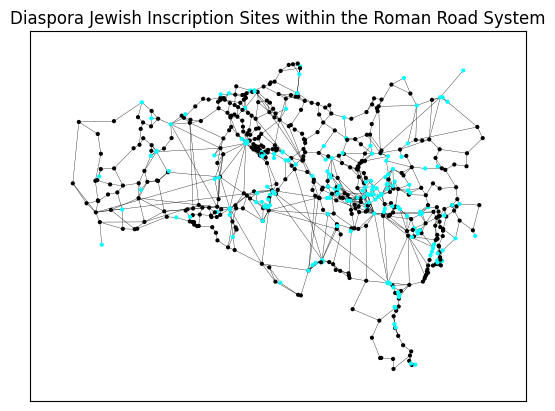

In [25]:
# draw inscription map
# TODO: add borders layer

# colors to use
colors_dict = {0 : "black", 1 : "cyan"}

pos = dict()
color = []
to_drop = []
for n in G_inscr.nodes:
   node_dict = G_inscr.nodes[n]
   if node_dict.get('x') is None: # drop orbis nodes with no long lat
       # print(n, G_inscr.nodes[n])
       to_drop.append(n)
   else:
       pos[n] = (G_inscr.nodes[n]['x'], G_inscr.nodes[n]['y'])
       if G_inscr.nodes[n]['inscr']==True:
           color.append(1)
       else: color.append(0)

for n in to_drop:
    G_inscr.remove_node(n)

# specify colors:
color = [colors_dict[c] for c in color]

plt.figure()
plt.title('Diaspora Jewish Inscription Sites within the Roman Road System')
nx.draw_networkx(G_inscr, pos, node_size=4, width=0.25,
                 node_color=color, with_labels=False)


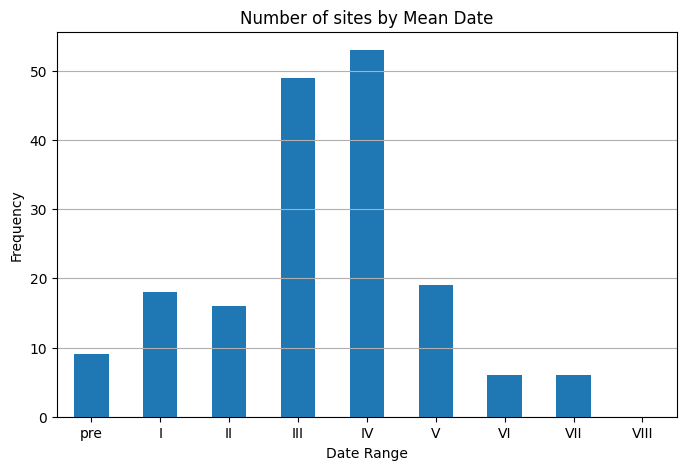

In [26]:
# plot inscription sites by *location*
# plotting by number will be skewed by high-inscription sites, especially Rome

bins = [-100,0,100,200,300,400,500,600,700,800]
lbls = ['pre','I','II','III','IV','V','VI','VII','VIII']

jewish_to_plot = df_locations[(df_locations['not before']>=-100) & (df_locations['not after']<800)]
jewish_cent_dist = pd.cut(jewish_to_plot['mean_date'],bins=bins,labels=lbls)

counts = jewish_cent_dist.value_counts(sort=False)

# 4. Plot
plt.figure(figsize=(8, 5))
counts.plot(kind='bar',rot=0)#, color='skyblue', edgecolor='black', rot=0)
plt.title('Number of sites by Mean Date')
plt.ylabel('Frequency')
plt.xlabel('Date Range')
plt.grid(axis='y')# , linestyle='--', alpha=0.7)
plt.show()

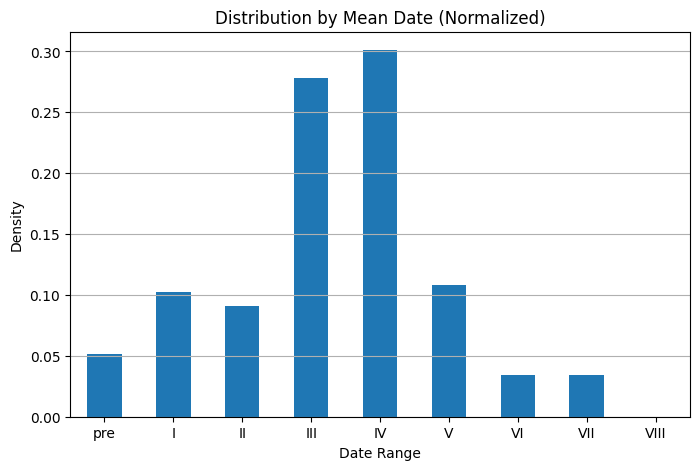

In [27]:
# normalized/density plot, for comparison with Greek and Latin inscriptions
counts = jewish_cent_dist.value_counts(sort=False,
                                       normalize=True) # for density

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', rot=0)#, color='skyblue', edgecolor='black', rot=0)
plt.title('Distribution by Mean Date (Normalized)')
plt.ylabel('Density')
plt.xlabel('Date Range')
plt.grid(axis='y')# , linestyle='--', alpha=0.7)
plt.show()

### Plot sites by mean weighted date of locations
`not_before`, `not_after`,`mean_date` are already averages by location. Set `century` based on mean date.


In [28]:
# create century column in df_locations
# bins = [-100,0,100,200,300,400,500,600,700,800]
# lbls = ['pre','I','II','III','IV','V','VI','VII','VIII']
bins = [-100,100,300,600,700]
lbls = ['pre-II','II-III','IV-V','VI-VII']

df_locations['century'] = pd.cut(df_locations['mean_date'],bins=bins,labels=lbls)

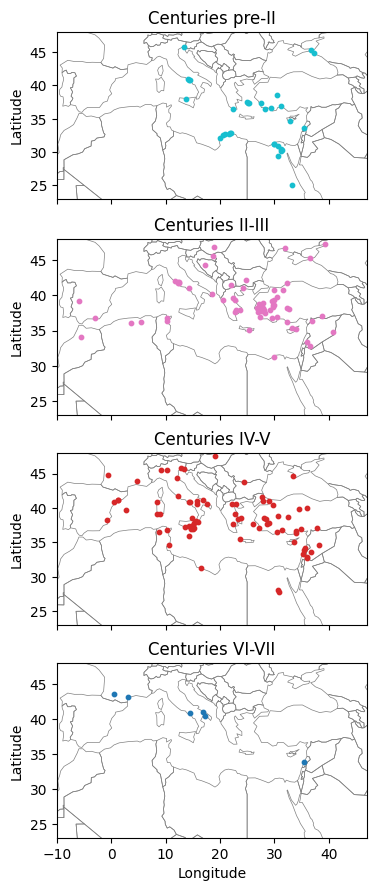

In [29]:
# chatGPT written
# crop world to Mediterranean
#restrict to mediterranean reigion

# world outline
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

med_bounds = {
    "minx": -10,   # west (Portugal/Morocco)
    "maxx": 47,    # east (Levant) + room for legend
    "miny": 23,    # south (North Africa)
    "maxy": 48     # north (Italy/Balkans)
}

world_med = world.cx[
    med_bounds["minx"]:med_bounds["maxx"],
    med_bounds["miny"]:med_bounds["maxy"]
]

# convert points to GeoDataFrame (WGS84 lon/lat)
gdf = gpd.GeoDataFrame(
    df_locations,
    geometry=gpd.points_from_xy(df_locations['long'], df_locations['lat']),
    crs="EPSG:4326"
)

# colors
cmap = mpl.colormaps['tab10_r']
colors = cmap(np.linspace(0, 1, len(lbls)))

# number of subplots
n = len(lbls)


fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(4, 2.75 * n),
    sharex=True,
    sharey=True
)
fig.subplots_adjust(hspace=0)

# ensure axes is iterable even if n == 1
if n == 1:
    axes = [axes]

for i, cent in enumerate(lbls):
    ax = axes[i]
    ax.set_ylabel("Latitude")

    # country outlinesc
    world_med.plot(
        ax=ax,
        color="none",
        edgecolor="grey",
        linewidth=0.5
    )

    # subset points for this century
    gdf_cent = gdf[gdf["century"] == cent]

    gdf_cent.plot(
        ax=ax,
        markersize=10,
        color=colors[i],
        # alpha=0.5,
        label=cent
    )

    # ax.legend(loc="upper right")

    # rotated PCA axes (same logic as before)
    scale = 20
    direction = [1, 1]

    # if model_rot.params['med_axis'] == abs(model_rot.params['med_axis']):
    #     direction[0] = -1
    # if model_rot.params['med_orth'] == abs(model_rot.params['med_orth']):
    #     direction[1] = -1

    # (actual plotting of axes omitted here since it wasn't in original code)

    ax.set_xlim(med_bounds["minx"], med_bounds["maxx"])
    ax.set_ylim(med_bounds["miny"], med_bounds["maxy"])

    ax.set_title(f"Centuries {cent}")

# shared labels
axes[-1].set_xlabel("Longitude")
# fig.text(0.04, 0.5, "Latitude", va="center", rotation="vertical")

plt.show()



Distribution does not increase only in the Western direction,  but clearly there are more insciptions in the Western Mediterraean in the second through fifth centuries than in the first.
   
Compare [this map published in the 1990s](https://www.pbs.org/wgbh/pages/frontline/shows/religion/maps/jewish.html):   


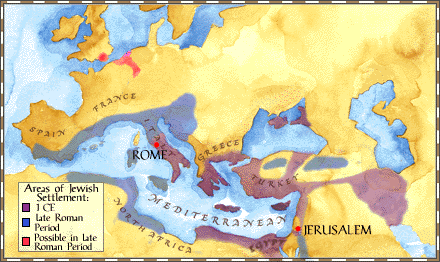

## Greek and Latin Inscriptions   
For recent discussion see:

> Heřmánková, P., Kaše, V., & Sobotkova, A. (2021). Inscriptions as data: digital epigraphy in macro-historical perspective. Journal of Digital History, 1(1). https://doi.org/10.1515/JDH-2021-1004?locatt=label:JDHFULL    

I use the following collections:
* **Greek (IPHI)**: Kaše, Vojtěch et al. 2023. “GIST.” Zenodo. https://doi.org/10.5281/zenodo.10139110.
>The
GIST dataset is primarily based on an online collection of ancient Greek inscriptions published
by the Packard Humanities Institute (PHI) and available via the Ithaca project as I.PHI [15].
A key feature of the dataset is that, wherever available, the spatial and temporal metadata are
expressed in a machine-readable form.    
>Sommerschield, Thea. (2021) 2025. “Sommerschield/Iphi.” Python. https://github.com/sommerschield/iphi.

* **Latin (EDH)** Epigraphic Database Heidelberg,
DOI 10.5281/zenodo.4888167

* **Latin (EDCSx)**: Epigraphic Database Clauss Slaby, https://doi.org/10.5281/zenodo.4888817, deduplicated from EDH as indicated by Heřmánková, et al. 2023  

**Notes:**
* Greek (IPHI) is skewed toward earlier periods. (If I did the calculation correctly, the Jewish inscriptions come from more places in LA than the Greek inscriptions, which is unlikely on the face of it.
* Due to the size of these datasets and the necessary downoad and processing times, I have provided pre-processed extracts for use here.



### Compare with Greek/Latin in general

In [30]:
df_inscr_binned = pd.read_csv('inscr_data_binned_density.csv', index_col=[0])
df_inscr_mean_dates = pd.read_csv('inscr_data_mean_dates.csv', index_col=[0])

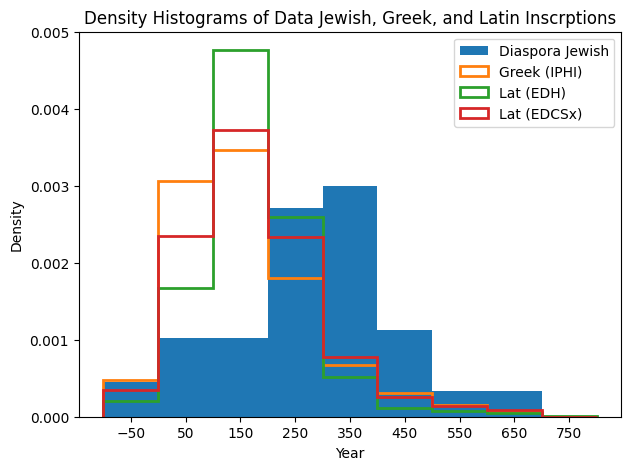

In [31]:
bins = range(-100,801,100)
plt.figure(figsize=(7, 5))
plt.title('Density Histograms of Data Jewish, Greek, and Latin Inscrptions')
plt.hist(df_inscr_mean_dates['Jewish'], density=True, bins=bins, label='Diaspora Jewish')
plt.hist(df_inscr_mean_dates['Greek (IPHI)'], density=True,bins=bins, histtype='step', linewidth=2, label='Greek (IPHI)')
plt.hist(df_inscr_mean_dates['Lat (EDH)'],density=True, bins=bins, histtype='step',linewidth=2, label='Lat (EDH)')
plt.hist(df_inscr_mean_dates['Lat (EDCSx)'],density=True, bins=bins, histtype='step', linewidth=2, label='Lat (EDCSx)')
# plt.hist(df_iip['Mean Date'],density=True, bins=bins, histtype='step', linewidth=2, label='IIP all'),
# plt.hist(df_iip_jewish['Mean Date'],density=True, bins=bins, histtype='step', linewidth=2, label='IIP Jewish')
plt.xticks(range(-50,751,100))
plt.xlabel('Year')
plt.ylabel('Density')
plt.legend()
plt.show()

Mann Whitney U

Cliff's delta divides Mann-Whitney by the lengths of the two series being compared, and ranges from 0 to 1

In [32]:
df_inscr_mean_dates = df_inscr_mean_dates[(df_inscr_mean_dates > -100) & (df_inscr_mean_dates <= 800)].copy()

SeriesA = df_inscr_mean_dates['Jewish'].dropna().rename('Diasp Jewish')
SeriesB = df_inscr_mean_dates['Greek (IPHI)'].dropna()
SeriesC = df_inscr_mean_dates['Lat (EDH)'].dropna()
SeriesD = df_inscr_mean_dates['Lat (EDCSx)'].dropna()

# A vs B
u_ab, p_ab = mannwhitneyu(
    SeriesA,
    SeriesB,
    alternative='two-sided'
)

# A vs C
u_ac, p_ac = mannwhitneyu(
    SeriesA,
    SeriesC,
    alternative='two-sided'
)

# A vs D
u_ad, p_ad = mannwhitneyu(
    SeriesA,
    SeriesD,
    alternative='two-sided'
)


print('Mann-Whitney, Cliff\'s Delta')
print('n. Jewish \t n. Gr-Lat \t\t Mann-Whitney U \t p \t Cliff\'s' )
print(len(SeriesA),
      '\t', len(SeriesB),
      '\t',f"{SeriesA.name} vs {SeriesB.name}:",
      '\t',u_ab,
      '\t',f"{p_ab:.2f}",
      '\t',f"{u_ab/(len(SeriesA)*len(SeriesB)):.2f}")
print(len(SeriesA),
      '\t',len(SeriesC),
      '\t',f"{SeriesA.name} vs {SeriesC.name}:",
      '\t',u_ac,
      '\t',f"{p_ac:.2f}",
      '\t',f"{u_ac/(len(SeriesA)*len(SeriesC)):.2f}")
print(len(SeriesA),
      '\t',len(SeriesD),
      '\t',f"{SeriesA.name} vs {SeriesD.name}:",
      '\t',u_ad,
      '\t', f"{p_ad:.2f}",
      '\t',f"{u_ad/(len(SeriesA)*len(SeriesD)):.2f}")


Mann-Whitney, Cliff's Delta
n. Jewish 	 n. Gr-Lat 		 Mann-Whitney U 	 p 	 Cliff's
177 	 593 	 Diasp Jewish vs Greek (IPHI): 	 80713.0 	 0.00 	 0.77
177 	 6808 	 Diasp Jewish vs Lat (EDH): 	 919046.0 	 0.00 	 0.76
177 	 5416 	 Diasp Jewish vs Lat (EDCSx): 	 714323.5 	 0.00 	 0.75


Box Plot   
The interquartile range of Jewish inscriptions barely overlaps with that of the other inscription sets.    
As with Mann-Whitney, they imply that the distributions are fundamentally different.

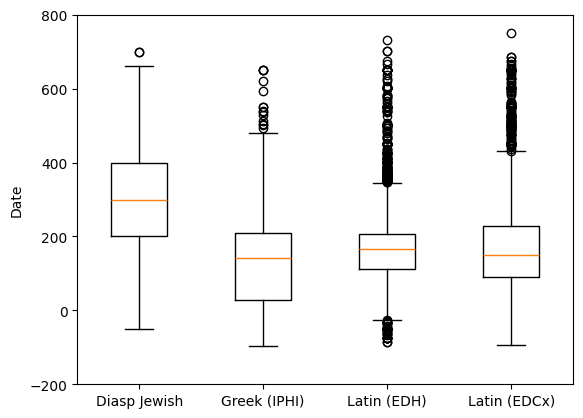

In [33]:
df_inscr_mean_dates.apply(pd.to_numeric,errors='coerce') # should not be necessary
plt.boxplot([SeriesA, SeriesB, SeriesC, SeriesD],
            tick_labels=["Diasp Jewish","Greek (IPHI)", "Latin (EDH)", "Latin (EDCx)"])

plt.ylabel("Date")
plt.yticks(range(-200,801,200))
plt.show()

## Observations
The corpus of "Jewish" inscriptions is for all intents and and purposes a subset of either the Greek or the Latin inscriptions. Nevertheless, they skew considerably later. (In the comparative histogram, the Jewish inscriptions reach there peak two centuries after all of the other comparanda.)    
This skew is statistically significant and interesting, although it is not clear how to interpret it. At a minimum, "exogenous" factors like massive revolts in Palestine, Egypt, Cyrene, and Cyprus, may have suppressed the "expected" number of inscriptions.   
In terms of numbers of inscriptions, the Jewish inscriptions bear some similarity to the distribution of inscriptions in EDCSx, with its disproportionate focus on Rome, but that similarity disappears when we factor only the sites where inscriptions occur.    
There is some similarity with the pattern of the spread of Christian sites as analyzed by Fousek, Jan et al. 2018. “Spatial Constraints on the Diffusion of Religious Innovations: The Case of Early Christianity in the Roman Empire.” Edited by Peter F. Biehl. PLOS ONE 13 (12): e0208744. https://doi.org/10.1371/journal.pone.0208744. Their data examines expansion through the beginning of the fourth century, and does not cover the later periods examined here.    
**Provisionally**: To the extent that Jewish inscription peak in the fourth century and westward spread appears to continue later (against likely demographic trends in the western Mediterranean), I am inclined to see this as at least partly specifically Jewish phenomenon.


# Regressions

* raw (rotated) longitude
* graph (Dijkstra) distance as constructed from Orbis
* kilometer-weighted graph distance as constructed from Orbis
* cost-weighted graph distance as constructed from Orbis, assuming an undirected graph (costs averaged)
* cost-weighted graph distance as constructed from Orbis, assuming a directed graph

In [34]:
# function to calculate for east-west anchors on graph
def east_west_anchors_on_graph(G, weight, site_data, axis):
  """
  Find the most eccentric nodes in G, that are the farthest East and West on axis
  args
    G : incoming graph
    weight: graph attribute to weight dijkstra calculation
    site_data : df with node ids, lat, long, med_axis (rotated long), med_orth (rotated lat)
    axis : axis to use (med_axis is the rotated longitude)
  """
  # get peripheral nodes from weighted graph:
  peripheral = pd.Series(nx.eccentricity(G,weight=weight), name='ecc')
  cutoff = peripheral.quantile(0.75)
  peripheral = peripheral[peripheral > cutoff]
  nodes = site_data.loc[site_data.index.isin(peripheral.index)]

  east_idx, east_coord, east_name = nodes.loc[nodes[axis].idxmax(),['idx',axis,'Place']].values
  west_idx, west_coord, west_name = nodes.loc[nodes[axis].idxmin(),['idx',axis,'Place']].values

  return  (east_idx, east_coord, east_name), (west_idx, west_coord, west_name)

In [35]:
# function to perform mixed effects linear regression.
# For comparison, between trials, the distance traversed is scaled to a [0,1] scale

# calculate regression on [0,1] scale
def mixed_linear(G, weight, site_data, axis,dist_mtx, east_anchor, west_anchor):
  """
  args
    G : graph (orbis or subgraph)
    weight : graph attribute for distance
    dist_mtx : a pre-calculated distance matrix on raw med_axis, cost, or km
    east_anchor, west_anchor
  """

  # # get anchors
  # anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G,weight,site_data,axis)
  # east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

  axis_metr = dist_mtx[east_anchor]/(dist_mtx[west_anchor] + dist_mtx[east_anchor])
  axis_metr.name = 'axis_metr'

  ### skiping the update of stored data dfs here ###
  to_regress = df_jewish[['Place','idx','weighted_date']].copy()
  to_regress = to_regress.merge(axis_metr,
                                left_on='idx',
                                right_index=True,
                                how='left')


  model_mixed_linear = smf.mixedlm(
      "weighted_date ~ axis_metr",
      to_regress,
      groups=to_regress["Place"]
  ).fit()
  print(model_mixed_linear.summary())

## Mixed effects model
TODO requires explication   
TODO parameterize and rewrite as functions

The regressions are carried out twice. The second time scales the East-West spatial displacement on a 0 to 1 scale. This makes the coefficient more interpretable (how many years does the dependent variable move over the entire East-to-West span). It also makes the different models, based on different scales, more directly comparable to one another.  

### Regress year against rotated longitude: "med_axis"

In [36]:
# get anchors: east-most and west-most points in the inscription graph
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,None,orbis_nodes_extended,'med_axis')
east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [37]:
# scaled to degrees
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ med_axis",
    df_jewish,
    groups=df_jewish["Place"]
).fit()

print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.2245    
Min. group size:  1       Log-Likelihood:     -7171.7399   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     303.441   12.423 24.425 0.000 279.092 327.790
med_axis       -4.528    1.076 -4.209 0.000  -6.636  -2.419
Group Var   21840.934   53.070                             



In [38]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
             df_dist_med_axis,
             east_anchor, west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.1802    
Min. group size:  1       Log-Likelihood:     -7167.5878   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept      197.160   22.216 8.875 0.000 153.619 240.702
axis_metr      199.613   46.334 4.308 0.000 108.799 290.426
Group Var    21746.948   52.852                            



### Regress year against EW axis (unweighted Dijkstra)

In [39]:
# # get anchors:
# anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_orbis_extended,None,orbis_nodes_extended,'med_axis')
# east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [40]:
# # using the distance matrix calculated earlier,
# # order sites along a an EW axis based on distance of each site
# # from anchors

# axis_ew = df_dist[west_anchor] - df_dist[east_anchor]


# df_axes = pd.DataFrame({
#     "idx": df_dist.index,
#     "axis_ew": axis_ew
# })



# df_locations = df_locations.merge(df_axes[['idx','axis_ew']],
#                                   on='idx')

In [41]:
# # apply to df_jewish
# print(len(df_jewish))
# df_jewish = df_jewish.merge(df_locations[['Place','axis_ew']],
#                             on='Place',
#                             how='left' )
# print(len(df_jewish))

In [42]:
# model_mixed_linear = smf.mixedlm(
#     "weighted_date ~ axis_ew",
#     df_jewish,
#     groups=df_jewish["Place"]
# ).fit()
# print(model_mixed_linear.summary())

In [43]:
# # on [0,1] scale
# mixed_linear(G_inscr,None,orbis_nodes_extended,'axis_ew',
#              df_dist,
#              east_anchor, west_anchor)

### Regress year against EW axis weighted Dijkstra (`km`)

In [44]:
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_orbis_extended,'km',orbis_nodes_extended,'med_axis')
east_anchor = anchor_data_e[0]
west_anchor = anchor_data_w[0]

In [45]:
orbis_nodes_extended[["Place", "long", "lat", "long_rad", "lat_rad", "idx"]]

,Place,long,lat,long_rad,lat_rad,idx
50001,Abodiacum,10.909000,47.909000,0.190398,0.836170,50001
50002,Ad fl. Tigrim,42.191000,37.341000,0.736372,0.651723,50002
50003,Ad Publicanos,6.374000,45.671000,0.111247,0.797109,50003
50004,Ad Tricesimum,13.215000,46.157000,0.230645,0.805592,50004
50005,Ad Aras,-0.977000,38.736000,-0.017052,0.676071,50005
...,...,...,...,...,...,...
90246,Termessos,30.462939,36.983662,0.531679,0.645487,90246
90247,Aspendos,31.169703,36.940372,0.544014,0.644731,90247
90249,Gdanmaa,32.561380,38.614766,0.568303,0.673955,90249
90251,Laodikaia Katakekaumene,32.374024,38.192186,0.565033,0.666579,90251


In [46]:
axis_ew_km = df_dist_km[west_anchor] - df_dist_km[east_anchor]


df_axes = pd.DataFrame({
    "idx": df_dist_km.index,
    "axis_ew_km": axis_ew_km
})



df_locations = df_locations.merge(df_axes[['idx','axis_ew_km']],
                                  on='idx')

In [47]:
# apply to df_jewish
print(len(df_jewish))
df_jewish = df_jewish.merge(df_locations[['Place','axis_ew_km']],
                            on='Place',
                            how='left' )
print(len(df_jewish))

1297
1297


In [48]:
model_mixed_linear = smf.mixedlm(
    "weighted_date ~ axis_ew_km",
    df_jewish,
    groups=df_jewish["Place"]
).fit()
print(model_mixed_linear.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2461.1193    
Min. group size:  1       Log-Likelihood:     -7177.3217   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     306.085   12.789 23.934 0.000 281.019 331.151
axis_ew_km     -0.022    0.005 -4.131 0.000  -0.033  -0.012
Group Var   21920.344   53.234                             



In [49]:
# on [0,1] scale
mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
             df_dist_km,
             east_anchor, west_anchor)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_date
No. Observations: 1297    Method:             REML         
No. Groups:       191     Scale:              2460.9954    
Min. group size:  1       Log-Likelihood:     -7168.6401   
Max. group size:  582     Converged:          Yes          
Mean group size:  6.8                                      
-----------------------------------------------------------
               Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept      184.726   26.544 6.959 0.000 132.701 236.751
axis_metr      240.576   60.744 3.960 0.000 121.520 359.633
Group Var    22087.101   53.592                            



### Regress year against EW axis weighted Dijkstra (`cost`, undirected)

In [50]:
# anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,'cost', orbis_nodes_extended,'med_axis')
# east_anchor = anchor_data_e[0]
# west_anchor = anchor_data_w[0]

In [51]:
# axis_ew_cost = df_dist_cost[west_anchor] - df_dist_cost[east_anchor]


# df_axes = pd.DataFrame({
#     "idx": df_dist_cost.index,
#     "axis_ew_cost": axis_ew_cost
# })



# df_locations = df_locations.merge(df_axes[['idx','axis_ew_cost']],
#                                   on='idx')

In [52]:
# # apply to df_jewsih
# df_jewish = df_jewish.merge(df_locations[['Place','axis_ew_cost']],
#                             on='Place',
#                             how='left' )

In [53]:
# model_mixed_linear = smf.mixedlm(
#     "weighted_date ~ axis_ew_cost",
#     df_jewish,
#     groups=df_jewish["Place"]
# ).fit()
# print(model_mixed_linear.summary())

In [54]:
# # on [0,1] scale
# mixed_linear(G_inscr,None,orbis_nodes_extended,'med_axis',
#              df_dist_cost,
#              east_anchor, west_anchor)

### Regress year against EW axis weighted Dijkstra (`cost`, directed)

In [55]:
# # get anchors
# anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,weight,orbis_nodes_extended,'med_axis')
# east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

In [56]:
# # directed graph weighted by 'expense'

# # all from w anchor
# from_west = nx.single_source_dijkstra_path_length(
#     D_orbis_extended,
#     west_anchor,
#     weight='expense'
# )

# # all sites to e anchor
# to_east = nx.single_source_dijkstra_path_length(
#     D_orbis_extended.reverse(),  # cool, would not have thought of this
#     east_anchor,
#     weight='cost'
# )

# axis_cost_dir = (
#     pd.Series(from_west)
#     - pd.Series(to_east)
# )
# axis_cost_dir.name = 'axis_cost_dir'

# df_locations = df_locations.merge(axis_cost_dir,
#                                   right_index=True,
#                                   left_on='idx',
#                                   how='left')


In [57]:
# # apply to df_jewsih
# df_jewish = df_jewish.merge(df_locations[['Place','axis_cost_dir']],
#                             on='Place',
#                             how='left' )

In [58]:
# model_mixed_linear = smf.mixedlm(
#     "weighted_date ~ axis_cost_dir",
#     df_jewish,
#     groups=df_jewish["Place"]
# ).fit()
# print(model_mixed_linear.summary())


In [59]:
# # on [0,1] scale
# mixed_linear(D_inscr,None,orbis_nodes_extended,'med_axis',df_dist_cost_asym, east_anchor,west_anchor)

## Bootstrapping
Bootstrapping to better model the uncertain dating of the inscriptions.   

Use stochastic sampling:
* from the sites with inscriptions, sample that number of sites with replacement
* from the inscrptions at each site, sample the number of inscriptions at that site, with replacement.
* based on the probability distribution of the inscription (e.g, 0.333 for each of the fourth, fifth, and sixth centuries) randomly assign a date.

In the summary data below, bootstrapping was repeated for 1000 iterations.   
Note that "sampling with replacement" means that sites and inscriptions can be duplicated in bootstrapped replicants.

### Code for bootstrapping

In [60]:
def resample_inscriptons(df, places):
  # resample_places
  # a list of places (can duplicate), from places eq in length to places
  sample_places = np.random.choice(
      places, size=len(places), replace=True
  )


  # within sample places resample inscriptions
  # same number of inscriptions as from site

  rows = []   # contains sampled inscriptions
  for p in sample_places:

    site_df = df[df['Place'] == p]  # all the inscriptions from that place

    sampled_inscr = site_df.sample(
        n=len(site_df), replace=True   # resample as many times as number of inscriptions
    )

    rows.append(sampled_inscr)
  bootstrap_df = pd.concat(rows, ignore_index=True)


  # stochastic dating
  bootstrap_df['date_draw'] = bootstrap_df['centuries'].apply(
    lambda x: random.choice(x)
  )
  return bootstrap_df


In [61]:
# for resampling, create a 'centuries' column with midpoints of possible
# centuries between start and end date

# 'centuries' column: list of midpoint of possible centuries
# TO FIX for calculation replace start and end with century start/end
def assign_cents(r, interval=100):
    start = r['not before']
    end = r['not after']
    intervals = pd.interval_range(start=start, end=end, freq=interval)
    dates = [int(i.mid) for i in intervals]
    return dates

df_jewish['centuries'] = df_jewish.apply(lambda r : assign_cents(r),axis=1)

In [62]:
# list of places for resampling (rather than extract each time?)
places = df_jewish['Place'].unique()

In [63]:
# east_west_anchors_on_graph(G, weight, site_data, axis)

In [64]:
# reproduces the whole process for each iteration

# dist_mtx = df_dist_med_axis
# axis = 'med_axis'
# weight = None

def mixed_linear_iterations(weight,axis,dist_mtx, iters=100):
  coeff = []
  intercept = []
  p_val = []
  conf_lower = []
  conf_upper = []


  for i in tqdm(range(0,iters)):

      # get anchors: east-most and west-most points in the inscription graph
      # these do not vary by trial (unless resample whole graph?) so can do them once at the beginning?
      anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_inscr,weight,orbis_nodes_extended,axis)
      east_anchor, west_anchor = anchor_data_e[0], anchor_data_w[0]

      bootstrap_df = resample_inscriptons(df_jewish, places)
      bootstrap_df = bootstrap_df.copy()

      # stochastic dating
      bootstrap_df['date_draw'] = bootstrap_df['centuries'].apply(
          lambda x: random.choice(x)
          )

      curr_axis_metr = dist_mtx[east_anchor]/(dist_mtx[west_anchor] + dist_mtx[east_anchor])
      curr_axis_metr.name = 'curr_axis_metr'

      ### skiping the update of stored data dfs here ###
      bootstrap_df = bootstrap_df.merge(curr_axis_metr,
                                    left_on='idx',
                                    right_index=True,
                                    how='left')

      # TODO need to understand why model may collapse
      try:
          model_samp = smf.mixedlm(
              "date_draw ~ curr_axis_metr",
              bootstrap_df,
              groups=bootstrap_df["Place"]
          ).fit(reml=False, disp=False)


      except Exception:
          print('no')
          # mixed models occasionally fail to converge in bootstraps
          continue

      coeff.append(model_samp.params['curr_axis_metr'])
      intercept.append(model_samp.params['Intercept'])
      p_val.append(model_samp.pvalues['curr_axis_metr'])
      conf_lower.append(model_samp.conf_int().loc['curr_axis_metr', 0])
      conf_upper.append(model_samp.conf_int().loc['curr_axis_metr', 1])

  df_results = pd.DataFrame({'coeff':coeff,
                             'intercept' : intercept,
                             'p_val':p_val,
                             'conf_lower':conf_lower,
                             'conf_upper':conf_upper})

  return df_results


### Bootstrapping results I:   
* EW coordinates
* East-West on orbis graph using km distance weights

In [65]:
# following cells can be uncommented to run bootstropping

# alternatively saved bootstrap results can be read from file

med_axis_results = pd.read_csv('bootstrap_on_rotated_ew.csv')
dist_km_results = pd.read_csv('bootstrap_dijkstra_km.csv')

In [66]:
# dist_mtx = df_dist_med_axis
# axis = 'med_axis'
# weight = None


# iters = 1000

# med_axis_results = mixed_linear_iterations(weight,axis,dist_mtx,iters)
med_axis_results.describe()

,coeff,intercept,p_val,conf_lower,conf_upper
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,259.979741,149.707751,3.136657e-03,113.288199,406.671283
std,45.318845,23.923320,1.042415e-02,45.226997,47.017365
min,97.195679,66.134174,4.936770e-08,-50.712837,245.104196
25%,230.518433,134.414934,9.606804e-05,83.552803,375.767384
50%,260.686825,150.940254,5.022892e-04,113.947872,406.222666
75%,289.968648,164.937162,2.110985e-03,143.090271,436.945087
max,406.886314,237.974465,1.977604e-01,248.228698,565.712270


In [67]:
# # graph distance weighted by orbis km values

# dist_mtx = df_dist_km
# axis = 'med_axis'
# weight = 'km'


# #iters = 1000

# dist_km_results = mixed_linear_iterations(weight,axis,dist_mtx,iters)
dist_km_results.describe()

,coeff,intercept,p_val,conf_lower,conf_upper
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,312.008007,132.265104,6.022224e-03,120.711501,503.304513
std,58.958864,28.519070,1.573349e-02,58.182440,61.955715
min,89.925264,34.798195,1.623235e-07,-87.089217,266.939745
25%,273.058675,113.845850,3.494921e-04,83.429265,462.424745
50%,310.967399,133.043644,1.392933e-03,120.558901,502.435452
75%,348.562390,151.413988,4.732375e-03,158.127289,544.225305
max,501.856791,216.381364,3.194043e-01,305.819288,720.977432


### Bootstrapping results II:
* unweighted graph distance
* graph distance weighted by Orbis cost estimates (symmetrical)
* graph distance weighted by orbis cost estimates (asymmetrical)   

In [68]:
# Uncomment following cells to run, alternatively read the results

unweighted_dijkstra_results = pd.read_csv('bootstrap_dijkstra_unweighted.csv')
symmetric_cost_results = pd.read_csv('bootstrap_dijkstra_on_cost_sym.csv')
asymmetric_cost_results = pd.read_csv('bootstrap_dijkstra_on_cost_asym.csv')


In [69]:
# dijkstra unweighted graph distance
dist_mtx = df_dist
axis = 'med_axis'
weight = None

iters = 1000

unweighted_dijkstra_results = mixed_linear_iterations(weight,axis,dist_mtx,iters)
unweighted_dijkstra_results.describe()

  0%|          | 0/1000 [00:00<?, ?it/s]

,coeff,intercept,p_val,conf_lower,conf_upper
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,143.916599,180.728650,0.411354,-168.982267,456.815465
std,87.104624,46.838866,0.248209,84.597990,96.724892
min,-168.613789,9.304530,0.015469,-523.640323,186.412744
25%,88.069988,151.152087,0.208268,-219.202279,391.829501
50%,140.420155,182.770936,0.376778,-171.049136,452.359046
75%,198.919472,211.000830,0.562625,-111.427135,514.778365
max,453.507166,329.896022,0.999439,82.464592,824.549739


In [70]:
dist_mtx = df_dist_cost
axis = 'med_axis'
weight = 'cost'

iters = 1000

symmetric_cost_results = mixed_linear_iterations(weight,axis,dist_mtx,iters)

symmetric_cost_results.describe()


  0%|          | 0/1000 [00:00<?, ?it/s]

,coeff,intercept,p_val,conf_lower,conf_upper
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,622.314259,-17.746033,0.131679,-62.054128,1306.682645
std,346.063939,156.491596,0.112727,233.262435,474.881264
min,137.274752,-1050.580944,0.000013,-543.476410,660.319675
25%,404.039696,-63.105717,0.049652,-202.853198,991.504649
50%,532.942585,20.319859,0.100461,-104.163056,1185.653389
75%,724.585563,81.293371,0.187589,0.907019,1448.791501
max,2865.066363,196.768306,0.655557,1570.994538,4171.545106


In [71]:
dist_mtx = df_dist_cost_asym
axis = 'med_axis'
weight = 'cost'

iters = 1000


asymmetric_cost_results = mixed_linear_iterations(weight,axis,dist_mtx,iters)

asymmetric_cost_results.describe()

  0%|          | 0/1000 [00:00<?, ?it/s]

,coeff,intercept,p_val,conf_lower,conf_upper
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,631.964247,-5.172603,0.117757,-45.179196,1309.107690
std,321.871525,136.605575,0.102301,220.554870,437.254450
min,119.647442,-786.103207,0.000047,-523.116085,664.225073
25%,417.807148,-50.950047,0.040226,-182.744750,1012.974645
50%,547.604739,29.402658,0.092725,-90.579312,1189.682237
75%,739.840772,84.197897,0.168011,29.214127,1460.289145
max,2434.017860,206.525811,0.666746,1242.666447,3625.369273


In [72]:
# If running the commented cells, optionally save
# med_axis_results.to_csv('bootstrap_on_rotated_ew.csv',index=False)
# dist_km_results.to_csv('bootstrap_dijkstra_km.csv',index=False)


# unweighted_dijkstra_results.to_csv('bootstrap_dijkstra_unweighted.csv',index=False)
# symmetric_cost_results.to_csv('bootstrap_dijkstra_on_cost_sym.csv',index=False)
# asymmetric_cost_results.to_csv('bootstrap_dijkstra_on_cost_ssym.csv',index=False)


### Bootstrap summary

The following table summarizes the mean results of the bootstraps for each of the test cases.    


|                  | coeff    | intercept | p_val    | conf_lower | conf_upper |
| ---------------- | --------: | ---------: | --------: | ----------: | ----------: |
| EW coords        | 259.9797 | 149.7078  | 0.003 | 113.2882   | 406.671   |
| Orbis km         | 312.008  | 132.2651  | 0.006 | 120.7115   | 503.305   |
| Orbis unweighted | 143.917	| 180.729	| 0.411	| \-168.982 | 456.815 |
| Orbis cost (sym) | 622.314 |	\-17.746 |	0.132 |	\-62.054 | 1306.683 |
| Orbis cost (asym) | 631.964	| \-5.173	| 0.118	| \-45.179 |	1309.100  |

The results show that only the models based on East-West coordinates and on the Orbis graph weighted by km distance gave consistently statistically significant results and were always in the positive range (i.e., always in the East-to-West direction) for the 95% confidence interval. As before, the graph weighting by distance has a somewhat stronger coefficient than the East-West displacement alone, implying that that the road-based model provides a better framework for modeling distances between sites.   

The following cell graphs the distribution of the coeefficient for the Orbis km-weighted bootstrap. The vertical line marks where the single regression before sampling. The sampling process is consistent with a greater (i.e., over more years) average displacement from East to West.


> **Note**: The data in each row is from a previous run of the notebook. Because of random sampling these results may differ slightly from new runs or from the saved data.

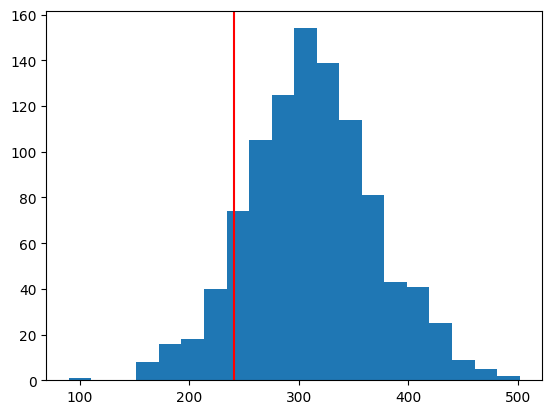

In [73]:
# The single regression coeeficient (red line) compared to the
# distribution of the regression coefficients from our bootstrapping
# runs that sampled sites and inscriptions and assigned dates using
# randomly (stochastically) based on the likelihoods from assigned possible dates

plt.hist(dist_km_results['coeff'], bins=20)
plt.axvline(240.576, color='red') # value from single run above



## Observations    
Regression on travel distance (as based on the kilometer length of segments in the Orbis graph) correlates closely with that of raw longitude, and may provisionally be taken to be a stronger result that takes into account graph topology. That result implies an average shift of 280 years from East to West.    
Using the cost metric yielded somewhat fragile results (less likely to be statistically valid, and susceptible to different endpoints). The results of the directed cost trial are interesting because the imply an earlier origin (intercept of 88) and a longer temporal displacement (450 years)

#Model movement?

Base on prior trials, using graph km distances to model movement

## Heat diffusion equation -- unhelpful results
TODO: return to this?
https://www.sciencedirect.com/topics/computer-science/heat-diffusion

The heat equation (also known as the diffusion equation) describes a time-varying evolution of a function u(x, t) given its initial distribution u(x, 0). Physically, this PDE is used to determine the spatial distribution of temperature on a conductive surface after it diffuses for time t:    
(10)(Heat equation): ∂∂tu(x,t)=Δxu(x,t)s.t.u(x,0)=f(x).

**The heat kernel kt(x, y)** specifies the transition density function from x to y over a time period t:   
(11) kt(x,y)=∑i=0∞e−λitϕi(x)ϕi(y).

Results:
* by site: unhelpful
* pooling regions: **Too much missing data** need to return to this


##Correlate first visibility with graph distance

Calculate the Spearman rank correlation (rho) site pairs with respect to other sites comparing  distance and time interval.

[Wikipedia](https://https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient):
>In statistics, Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated. It could be used in a situation where one only has ranked data, such as a tally of gold, silver, and bronze medals. If a statistician wanted to know whether people who are high ranking in sprinting [or: *sites that are closer to or more distant from all the others* --HL] are also high ranking in long-distance running [or: *sites  closer to or more distant in time from all the others* --HL], they would use a Spearman rank correlation coefficient.

In [ ]:
def weighted_median_centuries(Y_observed, centuries):
    """
    Vectorized weighted median century for inscr sites

    Parameters
    ----------
    Y_observed : pd.DataFrame
        Site x century matrix of fractional inscription weights
    centuries : list
        Ordered century labels in chronological order

    Returns
    -------
    pd.Series of weighted median century per site (as integer index into centuries)
    """
    # Normalize rows to handle weights that don't sum to exactly 1
    row_totals = Y_observed[centuries].sum(axis=1) # pd.Series
    normalized = Y_observed[centuries].div(row_totals, axis=0) # pd.Series

    # Cumulative sum across centuries (axis=1)
    # (each column has cumul of preceding in normzlied)
    cumulative = normalized.cumsum(axis=1)

    # For each site, first century where cumulative >= 0.5
    # idxmax return first index where this is true
    median_centuries = (cumulative >= 0.5).idxmax(axis=1)

    # Warn on any sites where max cumulative < 0.5
    problem_sites = cumulative[centuries[-1]][cumulative[centuries[-1]] < 0.5]
    if len(problem_sites) > 0:
        import warnings
        warnings.warn(f"{len(problem_sites)} sites have cumulative weight < 0.5: "
                      f"{list(problem_sites.index)}")

    # Sites with zero total weight get NaN
    median_centuries[row_totals == 0] = np.nan

    return median_centuries

In [ ]:
def pairwise_network_time_correlation(G, df_inscr, weight='weight'):
    """
    Test whether network cost distance between inscription site pairs
    predicts difference in epigraphic appearance time.

    Parameters
    ----------
    G : nx.Graph
        G_orbis_inscr or G_orbis — must contain inscription sites as nodes
    df_jewish : pd.DataFrame

    weight : str
        Edge weight attribute to use for Dijkstra distances
    Returns
    -------
    rho : float
        Spearman rank correlation between network distance and time difference
    pval : float
        Two-tailed p-value
    n_pairs : int
        Number of site pairs used

    """

    Y_observed = df_inscr[centuries].copy()
    weighted_date = df_inscr['weighted_date']
    insc_idx = df_inscr['idx']

    # Drop inscriptions with no weighted date
    weighted_date = weighted_date.dropna()
    sites = list(weighted_date.index) # really, inscriptions at sites rather than sites

    # Precompute all-pairs distances in n passes (not n^2)
    # single_source_dijkstra_path_length returns dict of {node: distance}
    distances = {}
    for s in sites:
        lengths = nx.single_source_dijkstra_path_length(
            G, insc_idx[s], weight=weight
        )
        # Keep only inscription sites
        distances[insc_idx[s]] = {
            insc_idx[t]: lengths[insc_idx[t]] for t in sites if insc_idx[t] in lengths
        }

    # Step 3: compute pairwise network distances and time differences
    dist_diffs = []
    time_diffs = []
    skipped = 0

    for s1, s2 in combinations(sites, 2):
        d = distances[insc_idx[s1]].get(insc_idx[s2], None)
        if d is None:
            skipped += 1
            continue
        t_diff = abs(weighted_date[s1] - weighted_date[s2])
        dist_diffs.append(d)
        time_diffs.append(t_diff)

    if len(dist_diffs) < 3:
        raise ValueError(f"Too few connected pairs ({len(dist_diffs)}) to correlate.")

    # rho, pval = spearmanr(dist_diffs, time_diffs)

    # print(f"Pairs used: {len(dist_diffs)}, skipped (no path): {skipped}")
    # print(f"Spearman rho: {rho:.3f}, p-value: {pval:.4f}")

    from scipy.stats import spearmanr, kendalltau
    rho, pval_s = spearmanr(dist_diffs, time_diffs)
    tau, pval_k = kendalltau(dist_diffs, time_diffs)

    print(f"Spearman rho: {rho:.3f}, p-value: {pval_s:.4f}")
    print(f"Kendall tau: {tau:.3f}, p-value: {pval_k:.4f}")

    print(f"\nProbability (based on Kendall's tau) that in any site-pair comparisons \
          \nthe site-pair with higher network distance will also have greater time difference:")
    print(f"P(concordant) = (tau + 1) / 2: {(tau + 1) / 2:.3f}")

    return rho, pval_s, len(dist_diffs)

In [ ]:
centuries = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
century_weights = [50, 150, 250, 350, 450, 550, 650, 750]
Y_observed = df_jewish[centuries].copy()
insc_idx = df_jewish['idx']

The combined rho value for the entire set of inscriptions. The results suggest a modest but measurable correlation.

In [ ]:
rho, pval, no_of_site_pairs = pairwise_network_time_correlation(G_inscr, df_jewish, weight='km')

Spearman rho: 0.459, p-value: 0.0000
Kendall tau: 0.327, p-value: 0.0000

Probability (based on Kendall's tau) that in any site-pair comparisons           
the site-pair with higher network distance will also have greater time difference:
P(concordant) = (tau + 1) / 2: 0.663


## Gradient of first site visibility by century

Spearman's rho does not have a spatial dimension: it measures the correlation between graph distance (in any direction) and time differences.    
When rho is calculated from each point on the inscriptions graph and plotted on geocoordinates, there is a clear gradient from East to West. (Implicitly, sites to the East are more likely to have served as the origin for all the other sites than sites to the West.)    
Here we resample the data over multiple iterations and plot the median value of Spearman's rho.


In [ ]:
# calcuate a matrix of distances between all sites on the inscriptions graph

inscr_pairs = df_dist_km.stack().reset_index() # convert long format
inscr_pairs.columns=(['sources','targets','km'])

# drop self pairs
inscr_pairs = inscr_pairs[inscr_pairs['km']>0]
# deduplicate
inscr_pairs['pairs'] = inscr_pairs.apply(
    lambda r: '_'.join(sorted([str(int(r['sources'])), str(int(r['targets']))])),
    axis=1
)

inscr_pairs.drop_duplicates(subset=['pairs'], inplace=True)
inscr_pairs.reset_index(inplace=True)
inscr_pairs

,index,sources,targets,km,pairs
0,1,50001,50056,54.539000,50001_50056
1,2,50001,50100,50.135000,50001_50100
2,3,50001,50293,65.681000,50001_50293
3,4,50001,50473,225.368000,50001_50473
4,5,50001,50002,3765.382963,50001_50002
...,...,...,...,...,...
340720,679796,90247,90251,381.591764,90247_90251
340721,679797,90247,90252,411.718390,90247_90252
340722,680622,90249,90251,121.601166,90249_90251
340723,680623,90249,90252,104.550521,90249_90252


In [ ]:
## necessary? or can we do it without bootstrap?


def sample_site_date_bootstrap_vect(df_inscr, century_cols, century_dates, n_iterations):
    """
    For each site, sample n inscriptions with replacement (n = number of
    inscriptions at site), draw a date for each from its century weight
    distribution, and take the mean as the site's date for that iteration.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Must have columns: 'idx' (site id), and century_cols
    century_cols : list of str
        Ordered century column names e.g. ['Pre-II', 'II', 'III', ...]
    century_dates : list of float
        Midpoint year for each century e.g. [50, 150, 250, ...]
        Must be same length and order as century_cols
    n_iterations : int

    Returns
    -------
    site_date_matrix : np.ndarray, shape (n_iterations, n_sites)
    site_idx_order : list
        Site idx values corresponding to columns of site_date_matrix
    """
    century_dates_arr = np.array(century_dates, dtype=float)
    n_centuries = len(century_cols)

    # Group inscriptions by site, preserving only century weight columns
    site_groups = {
        site_idx: group[century_cols].values.astype(float)
        for site_idx, group in df_inscr.groupby('idx')
    }

    site_idx_order = list(site_groups.keys())
    n_sites = len(site_idx_order)
    site_date_matrix = np.full((n_iterations, n_sites), np.nan)



    for j, site_idx in enumerate(site_idx_order):

        # weights: shape (n_inscriptions, n_centuries) — always 2D
        weights = site_groups[site_idx]
        if weights.ndim == 1:
            weights = weights.reshape(1, n_centuries)

        # Normalize each row to sum to 1, drop zero-weight rows
        row_totals = weights.sum(axis=1)          # shape (n_inscriptions,)
        valid = row_totals > 0


        if not valid.any():
            print(f"Site {site_idx}: all inscriptions have zero weight")
            print(f"  weights:\n{weights}")

        if np.isnan(weights).any():
            print(f"Site {site_idx}: NaN values in weights before filtering")
            print(f"  weights:\n{weights}")

        weights = weights[valid]
        row_totals = row_totals[valid]

        if len(weights) == 0:
            continue

        weights = weights / row_totals[:, np.newaxis]  # shape (n_inscriptions, n_centuries)
        n_inscriptions = len(weights)

        # Sample n_inscriptions indices with replacement across all iterations
        # shape: (n_iterations, n_inscriptions)
        insc_samples = np.random.randint(
            0, n_inscriptions, size=(n_iterations, n_inscriptions)
        )

        # Gather sampled weight rows
        # shape: (n_iterations, n_inscriptions, n_centuries)
        sampled_weights = weights[insc_samples]

        # Cumulative sum across century axis
        # shape: (n_iterations, n_inscriptions, n_centuries)
        cum_weights = np.cumsum(sampled_weights, axis=2)

        # Draw uniform random values
        # shape: (n_iterations, n_inscriptions, 1)
        u = np.random.uniform(size=(n_iterations, n_inscriptions, 1))

        # First century index where cumulative weight exceeds u
        # shape: (n_iterations, n_inscriptions)
        century_indices = (cum_weights < u).sum(axis=2)
        century_indices = np.clip(century_indices, 0, n_centuries - 1)

        # Map indices to dates
        # shape: (n_iterations, n_inscriptions)
        drawn_dates = century_dates_arr[century_indices]

        # Mean across inscriptions for each iteration
        # shape: (n_iterations,)
        site_date_matrix[:, j] = drawn_dates.mean(axis=1)

    return site_date_matrix, site_idx_order

In [ ]:
site_date_matrix, site_idx_order = sample_site_date_bootstrap_vect(df_jewish, centuries, century_weights, 1000)

In [ ]:
def score_origins_vectorized(df_inscr, df_inscr_pairs,
                              century_cols, century_dates,
                              n_iterations=1000):

    pair_costs = df_inscr_pairs.set_index('pairs')['km'].to_dict()

    site_names = df_locations.groupby('idx')['Place'].first().to_dict()
    site_groups = {
        site_idx: group
        for site_idx, group in df_inscr.groupby('idx')
    }
    origin_sites = list(site_groups.keys())

    # Step 1: precompute all sampled dates
    # shape: (n_iterations, n_sites)

    site_date_matrix, site_idx_order = sample_site_date_bootstrap_vect(
        df_jewish, century_cols, century_dates, 1000
        )

    # Map site_idx to column position in matrix
    site_col = {site: j for j, site in enumerate(site_idx_order)}

    # Step 2: precompute cost vector for each origin site
    # shape: (n_sites, n_sites) — cost from each origin to each target
    n_sites = len(site_idx_order)
    cost_matrix = np.full((n_sites, n_sites), np.nan)

    for i, origin_idx in enumerate(site_idx_order):
        for j, target_idx in enumerate(site_idx_order):
            if origin_idx == target_idx:
                continue
            pair = '_'.join(sorted(
                [str(origin_idx), str(target_idx)],
                key=lambda x: int(x)
            ))
            d = pair_costs.get(pair, None)
            if d is not None:
                cost_matrix[i, j] = d


    # Step 3: score each origin across all iterations
    rho_samples = {site: [] for site in origin_sites}


    ## problem populating rho samples
    for i, origin_idx in enumerate(origin_sites):
        col_i = site_col[origin_idx]

        # Cost vector from this origin to all other sites
        # excluding nan (unreachable or self)
        cost_vec = cost_matrix[col_i]
        reachable = ~np.isnan(cost_vec)
        reachable[col_i] = False  # exclude self

        if reachable.sum() < 3:
            continue

        costs = cost_vec[reachable]  # shape: (n_reachable,)

        # For each iteration, get date vector for reachable targets
        # shape: (n_iterations, n_reachable)
        date_matrix_iter = site_date_matrix[:, reachable]


        # Compute Spearman rho for each iteration
        for it in range(n_iterations):
            dates = date_matrix_iter[it]
            if np.any(np.isnan(dates)):
                continue
            rho, _ = spearmanr(costs, dates)
            rho_samples[origin_idx].append(rho)

    # Summarize
    results = []
    for site_idx, rhos in rho_samples.items():
        if len(rhos) == 0:
            continue
        rhos = np.array(rhos)
        results.append({
            'idx': site_idx,
            'site': site_names[site_idx],
            'rho_mean': rhos.mean(),
            'rho_median': np.median(rhos),
            'rho_lower': np.percentile(rhos, 2.5),
            'rho_upper': np.percentile(rhos, 97.5),
            'n_iterations': len(rhos)
        })

    return pd.DataFrame(results).sort_values('rho_mean', ascending=False)

In [ ]:
origin_candidates = score_origins_vectorized(df_jewish, inscr_pairs,
                              centuries, century_weights,
                              n_iterations=1000)

In [ ]:
### add new data to df_locations
df_locations = pd.merge(
    df_locations,
    origin_candidates[['idx','rho_median','rho_mean']],
    on='idx',
    how='left'
)
df_locations

,Place,Grouping,Region,Sub-Region,lat,long,pre II,II,III,IV,...,not before,not after,mean_date,idx,long_rad,lat_rad,century,axis_ew_km,rho_median,rho_mean
0,Admedera,Syria,Syria,Trachonitis and Batanaea,33.647580,36.664993,0.000000,0.000000,0.000000,0.000000,...,400.0,599.0,499.5,50388,0.639925,0.587261,IV-V,3999.500781,0.253135,0.252367
1,Adra,Iberian Penninsula,"Iberian Peninsula, Majorca, Minorca",Spain,36.748068,-3.022514,0.000000,0.000000,1.000000,0.000000,...,200.0,300.0,250.0,90122,-0.052753,0.641375,II-III,-3651.301572,-0.242777,-0.242121
2,Aegae,Asia Minor: Central,Asia Minor,Cilicia,38.832892,27.191722,0.000000,0.333333,0.333333,0.333333,...,100.0,399.0,249.5,90219,0.474585,0.677762,II-III,2007.847649,0.186760,0.186274
3,Aezani,Asia Minor: Central,Asia Minor,Phrygia,39.201251,29.609445,0.000000,1.000000,0.000000,0.000000,...,100.0,200.0,150.0,90234,0.516782,0.684191,II-III,2576.453841,0.190355,0.190382
4,Agrigento,"Sicily, Sardinia, Malta","Sicily, Sardinia, Malta",Sicily,37.290594,13.585475,0.000000,0.000000,0.000000,0.500000,...,300.0,499.0,399.5,50715,0.237111,0.650844,IV-V,-547.231657,-0.171986,-0.172167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,Villamesías,Iberian Penninsula,"Iberian Peninsula, Majorca, Minorca",Spain,39.245680,-5.873070,0.333333,0.333333,0.333333,0.000000,...,0.0,299.0,149.5,90128,-0.102504,0.684966,II-III,-4346.165985,-0.283234,-0.283909
187,Xenephyris,"Egypt, Delta",Egypt,Xenephyris (Kom el-Akhdar),25.086600,32.772600,2.000000,0.000000,0.000000,0.000000,...,-199.0,-50.0,-124.5,90170,0.571990,0.437844,NaN,2897.688289,0.332162,0.332431
188,al-Minya,"Egypt, Interior",Egypt,al-Minya,28.079479,30.726807,0.000000,0.166667,0.166667,0.166667,...,100.0,699.0,399.5,90157,0.536284,0.490079,IV-V,2897.688289,0.349895,0.349877
189,el Abrahamiya,"Egypt, Delta",Egypt,Alexandria,31.215077,29.927430,5.000000,0.000000,0.000000,0.000000,...,-349.0,-100.0,-224.5,90173,0.522332,0.544806,NaN,2812.965044,0.343240,0.343266


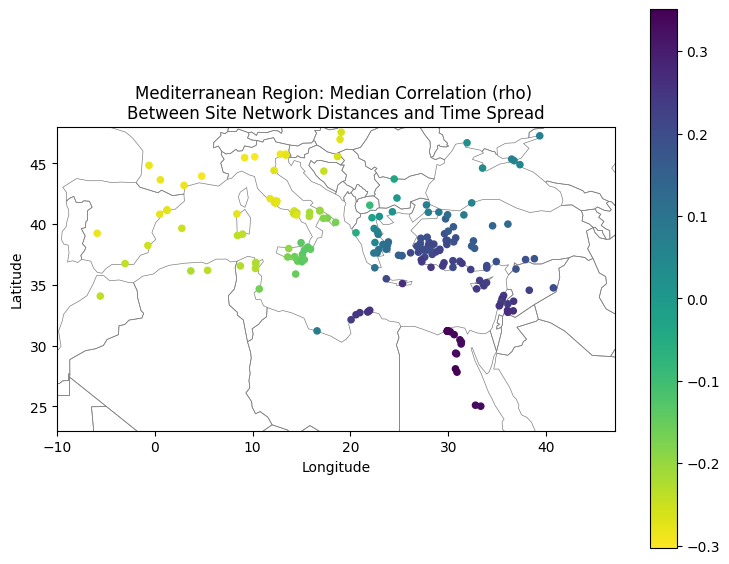

In [ ]:
## plot site as origin probabilities

gdf3 = gpd.GeoDataFrame(
    df_locations,
    geometry=gpd.points_from_xy(df_locations['long'], df_locations['lat']),
    crs='EPSG:4326'
)


fig, ax = plt.subplots(figsize=(9, 7))

# country outlines only
world_med.plot(
    ax=ax,
    color="none",
    edgecolor="grey",
    linewidth=0.5
)

#  points
gdf3.plot(
    ax=ax,
    markersize=20,
    column='rho_median',
    cmap='viridis_r',
    #alpha=0.4,
    legend=True
)

# also plot rotated pca axes
# PCA axes

scale = 20
direction = [1,1]
# if model_rot.params['med_axis'] == abs(model_rot.params['med_axis']):
#   direction[0] = -1
# if model_rot.params['med_orth'] == abs(model_rot.params['med_orth']):
#   direction[0] = -1


ax.set_xlim(med_bounds["minx"], med_bounds["maxx"])
ax.set_ylim(med_bounds["miny"], med_bounds["maxy"])

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("Mediterranean Region: Median Correlation (rho) \nBetween Site Network Distances and Time Spread")

plt.show()

## Plot the longitude (raw or rotated) of inscription graph center by century

In [ ]:
# revise for consistency and move up
cent_columns = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
cent_weights = [50, 150, 250, 350, 450, 550, 650, 750]
Y_observed = df_locations[cent_columns].copy()
insc_idx = df_jewish['idx']
site_idx_order = df_locations.index.to_list()
pair_costs = inscr_pairs.set_index('pairs')['km'].to_dict()

In [ ]:
def site_visibility_matrix(df_inscr, century_cols):
    """
    Compute probability that each site has at least one inscription
    visible by each century.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Inscription level data with 'idx' and century_cols
    century_cols : list
        Ordered century column names

    Returns
    -------
    pd.DataFrame: shape (n_sites, n_centuries)
        Values in [0, 1] representing site visibility probability
        Index = site idx
    """
    # Cumulative probability per inscription that it dates to <= century t
    # shape: (n_inscriptions, n_centuries)
    insc_cumulative = df_inscr[century_cols].cumsum(axis=1)

    # Probability inscription dates LATER than century t
    # = 1 - cumulative probability
    insc_later = 1 - insc_cumulative

    # For each site, probability ALL inscriptions date later than t
    # = product of individual probabilities
    # Take log, sum, exponentiate for numerical stability
    insc_later = insc_later.clip(lower=0)  # guard against float errors < 0

    log_later = np.log(insc_later.replace(0, np.nan))
    log_later['idx'] = df_inscr['idx'].values

    # Sum log probabilities within site
    log_sum = log_later.groupby('idx')[century_cols].sum()

    # P(at least one visible) = 1 - exp(sum of logs)
    # where nan in log_sum means at least one inscription
    # has probability 0 of being later — i.e. site is certainly visible
    p_all_later = np.exp(log_sum)
    p_all_later = p_all_later.fillna(0)  # certain visibility

    site_visibility = 1 - p_all_later

    return site_visibility

In [ ]:
def westward_shift(df_inscr, century_cols, century_dates):
    """
    Track the weighted mean longitude of epigraphic activity
    century by century, using new visibility weight each century.

    Parameters
    ----------
    df_inscr : pd.DataFrame
        Inscription level data with columns:
        'idx', 'Place',
        'long', 'lat',
        'med_axis', 'med_orth' [rotated axes above]
        and century_cols
    century_cols : list of str
        Ordered century column names
    century_dates : list of float
        Midpoint year for each century

    Returns
    -------
    pd.DataFrame with columns:
        century, century_date,
        weighted_mean_long, weighted_mean_lat,
        weighted_mean_axis, weighted_mean_orth,
        n_new_sites, new_weight,
        cumulative_mean_long, cumulative_mean_lat,
        cumulative_mean_axis, cumulative_mean_orth
    """
    # Site-level coordinates — one row per site
    site_coords = df_inscr.groupby('idx')[['long', 'lat','med_axis','med_orth']].first()

    # Site visibility matrix: shape (n_sites, n_centuries)
    # Values in [0,1] — probability site visible by century t
    visibility = site_visibility_matrix(df_inscr, century_cols)

    # Align coordinates with visibility index
    site_coords = site_coords.loc[visibility.index]

    results = []

    for t, (col, date) in enumerate(zip(century_cols, century_dates)):

        # New visibility weight this century
        if t == 0:
            new_weight = visibility[col].clip(lower=0)
        else:
            prev_col = century_cols[t - 1]
            new_weight = (
                visibility[col] - visibility[prev_col]
            ).clip(lower=0)

        # Cumulative visibility weight through this century
        cum_weight = visibility[col]

        # Active new sites
        active_new = new_weight[new_weight > 0]
        active_cum = cum_weight[cum_weight > 0]

        if len(active_new) == 0:
            results.append({
                'century': col,
                'century_date': date,
                'weighted_mean_long': np.nan,
                'weighted_mean_lat': np.nan,
                'weighted_mean_axis': np.nan,
                'weighted_mean_orth': np.nan,
                'n_new_sites': 0,
                'new_weight': 0.0,
                'cumulative_mean_long': np.nan,
                'cumulative_mean_lat': np.nan,
                'cumulative_mean_axis': np.nan,
                'cumulative_mean_orth': np.nan,

                'n_cumulative_sites': 0
            })
            continue

        # Weighted mean longitude and latitude of NEW sites
        new_longs = site_coords.loc[active_new.index, 'long'].values
        new_lats  = site_coords.loc[active_new.index, 'lat'].values
        new_axis = site_coords.loc[active_new.index, 'med_axis'].values
        new_orth  = site_coords.loc[active_new.index, 'med_orth'].values
        new_w     = active_new.values

        weighted_mean_long = (new_w * new_longs).sum() / new_w.sum()
        weighted_mean_lat  = (new_w * new_lats).sum()  / new_w.sum()
        weighted_mean_axis = (new_w * new_axis).sum() / new_w.sum()
        weighted_mean_orth = (new_w * new_orth).sum()  / new_w.sum()

        # Weighted mean longitude and latitude of ALL cumulative sites
        cum_longs = site_coords.loc[active_cum.index, 'long'].values
        cum_lats  = site_coords.loc[active_cum.index, 'lat'].values
        cum_axis = site_coords.loc[active_cum.index, 'med_axis'].values
        cum_orth = site_coords.loc[active_cum.index, 'med_orth'].values
        cum_w     = active_cum.values

        cumulative_mean_long = (cum_w * cum_longs).sum() / cum_w.sum()
        cumulative_mean_lat  = (cum_w * cum_lats).sum()  / cum_w.sum()
        cumulative_mean_axis = (cum_w * cum_axis).sum() / cum_w.sum()
        cumulative_mean_orth  = (cum_w * cum_orth).sum()  / cum_w.sum()

        results.append({
            'century': col,
            'century_date': date,
            'weighted_mean_long': weighted_mean_long,
            'weighted_mean_lat': weighted_mean_lat,
            'weighted_mean_axis': weighted_mean_axis,
            'weighted_mean_orth': weighted_mean_orth,
            'n_new_sites': len(active_new),
            'new_weight': new_w.sum(),
            'cumulative_mean_long': cumulative_mean_long,
            'cumulative_mean_lat': cumulative_mean_lat,
            'cumulative_mean_axis': cumulative_mean_axis,
            'cumulative_mean_orth': cumulative_mean_orth,
            'n_cumulative_sites': len(active_cum)
        })

    return pd.DataFrame(results)

In [ ]:
df_westward_shift = westward_shift(df_jewish,cent_columns, cent_weights)

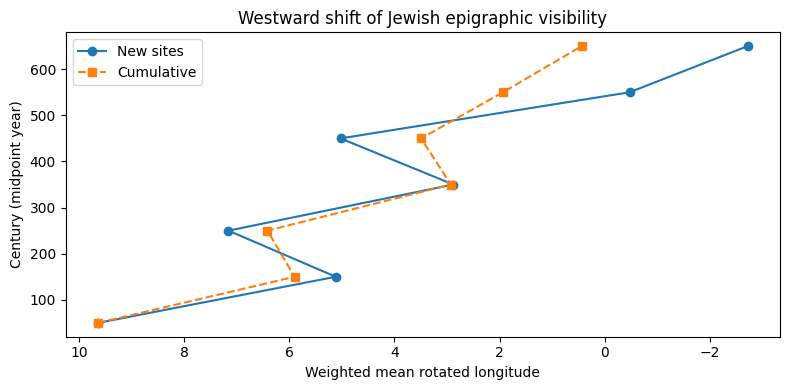

In [ ]:
df_shift = westward_shift(df_jewish, cent_columns, cent_weights)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_shift['weighted_mean_axis'],
        df_shift['century_date'],
        marker='o', label='New sites')
ax.plot(df_shift['cumulative_mean_axis'],
        df_shift['century_date'],
        marker='s', linestyle='--', label='Cumulative')

ax.set_ylabel('Century (midpoint year)')
ax.set_xlabel('Weighted mean rotated longitude')
ax.set_title('Westward shift of Jewish epigraphic visibility')
ax.legend()
ax.invert_xaxis()  # optional: west at top
plt.tight_layout()

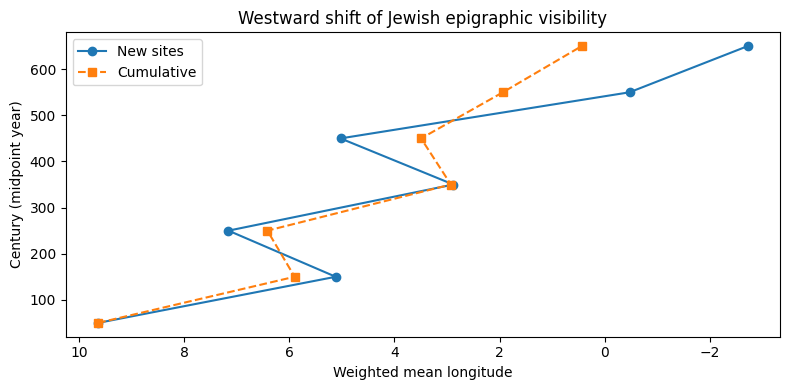

In [ ]:
df_shift = westward_shift(df_jewish, cent_columns, cent_weights)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_shift['weighted_mean_axis'],
        df_shift['century_date'],
        marker='o', label='New sites')
ax.plot(df_shift['cumulative_mean_axis'],
        df_shift['century_date'],
        marker='s', linestyle='--', label='Cumulative')

ax.set_ylabel('Century (midpoint year)')
ax.set_xlabel('Weighted mean longitude')
ax.set_title('Westward shift of Jewish epigraphic visibility')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()

## Observations
Distance between sites is positively correlated with time span between them. Although Spearman's rho is not sensitive to direction, plotting the median or mean rho of each site on the map shows a clear westward gradiant. Roughly speaking this fits with a propagation of sites across the Mediterranean from east to West.

Tracing the center of the graph as sites are added each century, similarly suggests westward movement. Results on raw or rotated longitude are more or less indistingusishable. Tracing the East-West position of the graph by century shows a westward trend (although not monotonic). Restricting the plot to sites that are added each century (`new sites`) shows much the same pattern, with a  pronounced Western shift for (the admittedly very few) new sites in the sixth and seventh centuries.

# Palestine as source
In this section we ask whether connection to Palestine in particular has an impact on the date or dispersion of inscriptions. We can show that "accessibility" to sites in Palestine is correlated with how early diaspora sites will have inscriptions.   
The problem is that Palestinian sites are on the eastern end of the Orbis data, so it is hard to distinguish the "effect" of Palestine in particular as opposed to a general westward trend. There may be a small "Palestine" effect, but it needs further exploration

## Read data
Repeats much of the processing for IIP data that was performed on the diaspora data.

In [ ]:
df_iip = pd.read_excel('IIP_inscriptions_copy.xlsx', index_col=None)

to_keep = ['IIP ID',
           'City Name',
           'Terminus ante quem',
           'Terminus post quem',
           'Likely religion',
           'Mean Date']

df_iip.drop(columns=[c for c in df_iip.columns if c not in to_keep], inplace=True)

# rename columns to map to diaspora inscriptions
df_iip.rename(columns={'City Name':'Place'},inplace=True)

# not_before and not_after columns
def not_before_after_cols(df, raw_not_before, raw_not_after):
    df['not before'] = df[raw_not_before] // 100 * 100
    # date after, including where end date = e.g., 600
    # np.select, like a case statement
    df['not after'] = np.select(
        [
            df[raw_not_after] < 0,          # BC Terminus post quems if relevant
            df[raw_not_after] % 100 == 0,   # exact century
        ],
        [
            (df[raw_not_after] // 100 + 1) * 100,  # e.g. -150 → -100
            df[raw_not_after],
        ],
        default=(df[raw_not_after] // 100 + 1) * 100
        )
    return df

# create "probablility" columns to match diaspora inscriptions
def assign_century_probabilities(df, not_before='not before', not_after='not after'):
    columns = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
    bins = [-100, 100, 200, 300, 400, 500, 600, 700, 800]
    for i, period in enumerate(columns):
        period_start = bins[i]
        period_end = bins[i + 1]
        # Total span is now exclusive of not_after (subtract 1)
        date_range = (df[not_after] - 1) - df[not_before]
        # Overlap between inscription range and this century bin
        overlap_start = df[[not_before]].assign(p=period_start).max(axis=1)
        overlap_end   = df[[not_after]].assign(p=period_end).min(axis=1) - 1
        overlap       = (overlap_end - overlap_start + 1).clip(lower=0)
        # Point date: not_before == not_after - 1 (i.e. single year)
        df[period] = np.where(
            date_range == 0,
            ((df[not_before] >= period_start) & (df[not_before] < period_end)).astype(float),
            overlap / (date_range + 1)
        )
    return df


not_before_after_cols(df_iip, 'Terminus ante quem', 'Terminus post quem')

if 'pre II' not in df_iip.columns: # just a test
    assign_century_probabilities(df_iip, not_before='not before', not_after='not after')

# drop missing values
df_iip.dropna(subset=['Place',
                 'pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII',
                 'not before', 'not after'], inplace=True)

# at least one inscription has a not_before date > not_after date
df_iip = df_iip[df_iip['not before']<=df_iip['not after']]


# weighted date column
century_cols = ['pre II', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII']
century_dates = [-50, 150, 250, 350, 450, 550, 650, 750] # take midpoint of century

df_iip['weighted_date'] = df_iip[century_cols].values @ century_dates
# multiply each probability per column by century_dates (midpoints of century)
# III to IV cent: III:0.5, IV:0.5 --> 125 + 175 = 300
# @ operator: dot product matrix multiplication
# equivalent to using np.matmult(A, B)

df_iip = df_iip[(df_iip['not before']>=-100) & (df_iip['not before']<=800)]

df_iip_non = df_iip[df_iip['Likely religion']!='jewish']
df_iip_jewish = df_iip[df_iip['Likely religion']=='jewish']

# aggregate by location I have a hand-edited Jewish one so not saving it here
agg_dict = {'IIP ID': 'first',
            'pre II': 'sum',
            'II': 'sum',
            'III': 'sum',
            'IV': 'sum',
            'V': 'sum',
            'VI': 'sum',
            'VII': 'sum',
            'VIII': 'sum',
            'not before': 'mean',
            'not after': 'mean',
            'weighted_date' : 'mean'}


locations_iip_all = df_iip.groupby(['Place']).agg(agg_dict).reset_index()
locations_iip_non = df_iip_non.groupby(['Place']).agg(agg_dict).reset_index()
locations_iip_jewish = df_iip_jewish.groupby(['Place']).agg(agg_dict).reset_index()

for df in [locations_iip_all, locations_iip_non, locations_iip_jewish]:
    # correct for legacy calculations using mean date?
    df['mean date'] = df['weighted_date']
    df['id'] = df['IIP ID'].str.replace(r'\d+','',regex=True)


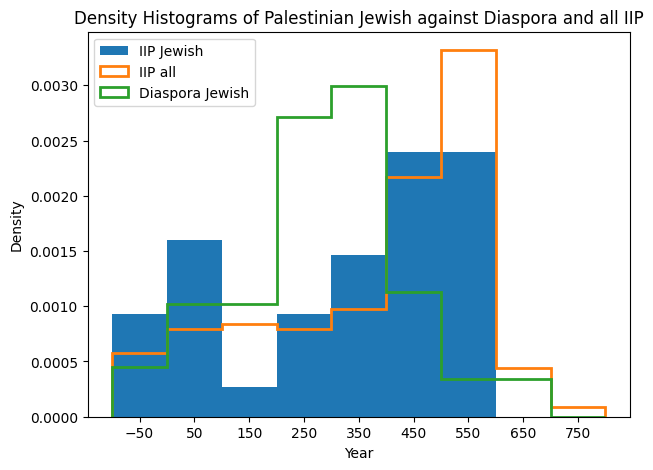

In [ ]:
bins = range(-100,801,100)
plt.figure(figsize=(7, 5))
plt.title('Density Histograms of Palestinian Jewish against Diaspora and all IIP')
plt.hist(locations_iip_jewish['mean date'],density=True, bins=bins, label='IIP Jewish')
plt.hist(locations_iip_all['mean date'],density=True, bins=bins, histtype='step', linewidth=2, label='IIP all'),
plt.hist(df_inscr_mean_dates['Jewish'], density=True, bins=bins, histtype='step', linewidth=2, label='Diaspora Jewish')
# plt.hist(df_inscr_mean_dates['Greek (IPHI)'], density=True,bins=bins, histtype='step', linewidth=2, label='Greek (IPHI)')
# plt.hist(df_inscr_mean_dates['Lat (EDH)'],density=True, bins=bins, histtype='step',linewidth=2, label='Lat (EDH)')
# plt.hist(df_inscr_mean_dates['Lat (EDCSx)'],density=True, bins=bins, histtype='step', linewidth=2, label='Lat (EDCSx)')
plt.xticks(range(-50,751,100))
plt.xlabel('Year')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
# get map refs
map_refs_iip = pd.read_csv('IIP_maprefs.csv')

#handle potential upload problems
map_refs_iip.dropna(subset=['long','lat'], inplace=True)
map_refs_iip['long'] = map_refs_iip['long'].astype('float')
map_refs_iip['lat'] = map_refs_iip['lat'].astype('float')

# for later calculation convert lat/long angle  to radian
map_refs_iip['long_rad'] = np.radians(map_refs_iip['long'])
map_refs_iip['lat_rad'] = np.radians(map_refs_iip['lat'])


# add idx column to df_iip_jewish from
df_iip_jewish = df_iip_jewish.merge(map_refs_iip[['Place','idx']],
                            on='Place',
                            how='left')

map_refs_iip.set_index('idx',drop=False,inplace=True)
map_refs_iip

,idx,Place,id,pleiades_url,pleiades_id,orbis_id,lat,long,long_rad,lat_rad
idx,,,,,,,,,,
80001,80001,Abilene,80001,https://pleiades.stoa.org/places/677994,677994.0,NaN,33.604603,36.029601,0.628835,0.586511
80002,80002,Ahmadiyye,80002,https://pleiades.stoa.org/places/794388243,794388243.0,NaN,33.000000,35.700000,0.623083,0.575959
50637,50637,Apollonia,80003,NaN,NaN,50637.0,32.213000,34.816000,0.607654,0.562223
50658,50658,Ashdod,80004,NaN,NaN,50658.0,31.800000,34.650000,0.604757,0.555015
50046,50046,Ashkelon,80005,https://pleiades.stoa.org/places/687839,687839.0,50046.0,31.669000,34.546000,0.602941,0.552728
...,...,...,...,...,...,...,...,...,...,...
80083,80083,Wadi Hamam,80083,NaN,NaN,NaN,32.828333,35.492222,0.619456,0.572962
80084,80084,Yavneh,80084,https://pleiades.stoa.org/places/687925,687925.0,NaN,31.876462,34.738425,0.606300,0.556349
80085,80085,Zoora,80085,https://pleiades.stoa.org/places/697768,697768.0,NaN,31.027273,35.481817,0.619275,0.541528


### Integrate with orbis data

In [ ]:
# extract map refs that do not appear in orbis
not_orbis_iip = map_refs_iip.loc[map_refs_iip['orbis_id'].isna()].copy()

# create dist matrix of not_orbis x orbis to find the three closest orbis site
# to not_orbis map refs
# use haversine distance to convert long/lat rad to km

# assisted by claude.ai
EARTH_RADIUS_KM = 6371.0



dist_matrix_iip_not_orbis_km = haversine_distances(
    not_orbis_iip[['lat_rad', 'long_rad']].values,
    orbis_nodes_extended[['lat_rad', 'long_rad']].values
    ) * EARTH_RADIUS_KM

print(dist_matrix_iip_not_orbis_km.shape)

# average of cost per km from orbis edges
costperkm = 0.016320598
distortion = 1.25 # true route lengths are longer than km displacement

dist_matrix_iip_not_orbis_cost = dist_matrix_iip_not_orbis_km * costperkm * distortion


# Get indices of 3 smallest distances per row
orbis_ids = orbis_nodes_extended.index.values
not_orbis_iip_ids = not_orbis_iip.index.values


# claude.ai, need to understand np.take_along_axis
top3_idx = np.argsort(dist_matrix_iip_not_orbis_cost, axis=1)[:, :3]
top3_cost = np.take_along_axis(dist_matrix_iip_not_orbis_cost, top3_idx, axis=1)
top3_km = np.take_along_axis(dist_matrix_iip_not_orbis_km, top3_idx, axis=1)
top3_ids = orbis_ids[top3_idx]

# Assign back to not_orbis
for i in range(3):
    not_orbis_iip[f'target{i+1}_id'] = top3_ids[:, i]
    not_orbis_iip[f'target{i+1}_cost'] = top3_cost[:, i]
    not_orbis_iip[f'target{i+1}_km'] = top3_km[:, i]

# nodes not in orbis to add
nodes_to_add_iip = not_orbis_iip[['Place','lat', 'long','lat_rad','long_rad']]
# # rename to match orbis columns ## should rename the opposite way
# nodes_to_add_iip.columns = ['label', 'y', 'x','lat_rad','long_rad']

# add these nodes to orbis nodes list

### At this point add the new points to orbis_extended_iip,
### which will have map/graph data for all sites in study


orbis_nodes_extended_iip = pd.concat([orbis_nodes_extended, nodes_to_add_iip])



(74, 818)


In [ ]:
orbis_nodes_extended

,Place,rank,long,lat,cost,target,province,modern,long_rad,lat_rad,med_axis,med_orth,med_axis_z,med_orth_z,idx
50001,Abodiacum,60.0,10.909000,47.909000,0.0,0.0,Raetia,Germany,0.190398,0.836170,-9.314083,5.811155,-0.720407,0.449469,50001
50002,Ad fl. Tigrim,60.0,42.191000,37.341000,0.0,0.0,Armenia,Turkey,0.736372,0.651723,23.642246,3.779757,1.828632,0.292349,50002
50003,Ad Publicanos,60.0,6.374000,45.671000,0.0,0.0,Narbonensis,France,0.111247,0.797109,-13.107198,2.466436,-1.013789,0.190769,50003
50004,Ad Tricesimum,60.0,13.215000,46.157000,0.0,0.0,Italia,Italy,0.230645,0.805592,-6.630551,4.722212,-0.512846,0.365244,50004
50005,Ad Aras,60.0,-0.977000,38.736000,0.0,0.0,Tarraconensis,Spain,-0.017052,0.676071,-18.391878,-6.147714,-1.422538,-0.475501,50005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90246,Termessos,NaN,30.462939,36.983662,NaN,NaN,NaN,NaN,0.531679,0.645487,12.414548,0.371839,0.960215,0.028760,90246
90247,Aspendos,NaN,31.169703,36.940372,NaN,NaN,NaN,NaN,0.544014,0.644731,13.108088,0.514635,1.013858,0.039805,90247
90249,Gdanmaa,NaN,32.561380,38.614766,NaN,NaN,NaN,NaN,0.568303,0.673955,14.014169,2.494377,1.083940,0.192930,90249
90251,Laodikaia Katakekaumene,NaN,32.374024,38.192186,NaN,NaN,NaN,NaN,0.565033,0.666579,13.943679,2.037532,1.078487,0.157595,90251


In [ ]:
# not entirely sure why I need this step
orbis_nodes_extended_iip['idx'] = orbis_nodes_extended_iip.index
orbis_nodes_extended_iip


,Place,rank,long,lat,cost,target,province,modern,long_rad,lat_rad,med_axis,med_orth,med_axis_z,med_orth_z,idx
50001,Abodiacum,60.0,10.909000,47.909000,0.0,0.0,Raetia,Germany,0.190398,0.836170,-9.314083,5.811155,-0.720407,0.449469,50001
50002,Ad fl. Tigrim,60.0,42.191000,37.341000,0.0,0.0,Armenia,Turkey,0.736372,0.651723,23.642246,3.779757,1.828632,0.292349,50002
50003,Ad Publicanos,60.0,6.374000,45.671000,0.0,0.0,Narbonensis,France,0.111247,0.797109,-13.107198,2.466436,-1.013789,0.190769,50003
50004,Ad Tricesimum,60.0,13.215000,46.157000,0.0,0.0,Italia,Italy,0.230645,0.805592,-6.630551,4.722212,-0.512846,0.365244,50004
50005,Ad Aras,60.0,-0.977000,38.736000,0.0,0.0,Tarraconensis,Spain,-0.017052,0.676071,-18.391878,-6.147714,-1.422538,-0.475501,50005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80083,Wadi Hamam,NaN,35.492222,32.828333,NaN,NaN,NaN,NaN,0.619456,0.572962,NaN,NaN,NaN,NaN,80083
80084,Yavneh,NaN,34.738425,31.876462,NaN,NaN,NaN,NaN,0.606300,0.556349,NaN,NaN,NaN,NaN,80084
80085,Zoora,NaN,35.481817,31.027273,NaN,NaN,NaN,NaN,0.619275,0.541528,NaN,NaN,NaN,NaN,80085
80086,Isawiyya,NaN,35.242274,31.792602,NaN,NaN,NaN,NaN,0.615094,0.554886,NaN,NaN,NaN,NaN,80086


In [ ]:
### append not_orbis pairs to edge list:
### Note: we don't actually use directed; kept for parallel/completeness

# for each inscr (not_orbis) node create edges
# with EACH of the three closest orbis nodes
edge_groups = []
edge_groups_reverse = []
for i in range(1,4):
  to_append = not_orbis_iip[['id',f'target{str(i)}_id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append.columns = ['source', 'target', 'expense', 'km']
  edge_groups.append(to_append)

  # for directed, simply mirror
  to_append_directed = not_orbis_iip[[f'target{str(i)}_id','id',f'target{str(i)}_cost',f'target{str(i)}_km']]
  to_append_directed.columns = ['source', 'target', 'expense', 'km']
  edge_groups_reverse.append(to_append_directed)

edges_to_add = pd.concat(edge_groups)
edges_to_add_reverse = pd.concat(edge_groups_reverse)

### At this point add the new edges to orbis_edges_extended_iip,
### which will have map/graph data for all sites in study

orbis_edges_extended_iip = pd.concat([
    orbis_edges_extended[['source','target','expense', 'km']],
    edges_to_add],
    ignore_index=True)
orbis_edges_extended_iip['combined'] = orbis_edges_extended_iip.apply(
    lambda row: ','.join(map(str, sorted([row['source'], row['target']]))),
    axis=1)

orbis_edges_directed_extended_iip = pd.concat([
    orbis_edges_directed_extended[['source','target','expense', 'km']],
    edges_to_add,
    edges_to_add_reverse],
    ignore_index=True)

In [ ]:
# get lat long columns etc. from maprefs_iip
if 'idx' in locations_iip_jewish.columns:
  print('skipping')

else:
  locations_iip_jewish = locations_iip_jewish.merge(
      map_refs_iip[['idx','Place', 'lat',
        'long', 'long_rad', 'lat_rad']],
      on='Place'
  )
  locations_iip_jewish


In [ ]:
## add classifying pal_diasp` column

orbis_nodes_extended_iip['pal_diasp'] = ''
orbis_nodes_extended_iip.loc[orbis_nodes_extended_iip['idx'].isin(df_locations['idx']), 'pal_diasp'] = 'diaspora'
orbis_nodes_extended_iip.loc[orbis_nodes_extended_iip['idx'].isin(locations_iip_jewish['idx']), 'pal_diasp'] = 'palestine'
orbis_nodes_extended_iip[['Place','idx','pal_diasp']]

,Place,idx,pal_diasp
50001,Abodiacum,50001,
50002,Ad fl. Tigrim,50002,
50003,Ad Publicanos,50003,
50004,Ad Tricesimum,50004,
50005,Ad Aras,50005,
...,...,...,...
80083,Wadi Hamam,80083,palestine
80084,Yavneh,80084,palestine
80085,Zoora,80085,palestine
80086,Isawiyya,80086,


### Graph creation
* skipping directed graph
* adding to G_orbis_extended

In [ ]:
orbis_nodes_extended_iip.columns

Index(['Place', 'rank', 'long', 'lat', 'cost', 'target', 'province', 'modern',
       'long_rad', 'lat_rad', 'med_axis', 'med_orth', 'med_axis_z',
       'med_orth_z', 'idx', 'pal_diasp'],
      dtype='object')

In [ ]:
# create graph of orbis_edges_extended
G_orbis_extended_iip = nx.from_pandas_edgelist(
    orbis_edges_extended_iip,
    source='source',
    target='target',
    edge_attr=['expense', 'km'],  # Include the 'weight' column as an edge attribute
)

# node attributes
# set id column as key of dict
node_attrs_dict = orbis_nodes_extended_iip.to_dict(orient='index')
# print(node_attrs_dict)

# add nodes
nx.set_node_attributes(G_orbis_extended_iip, node_attrs_dict)

### Site-to-site distance matrices

Retaining only distance matrice on graph (Dijkstra) distance weighted by `km`.

In [ ]:
### creating `D_km_extended` in case there is a reason to keep original

nodes = list(G_orbis_extended_iip.nodes)
node_index = {n: i for i, n in enumerate(nodes)}

# we want a sublist of inscription sites
inscr_sites = list(df_jewish['idx'].unique())
inscr_sites_iip = list(df_iip_jewish['idx'].unique())
print(len(inscr_sites_iip), len(inscr_sites))
inscr_sites_iip = inscr_sites + inscr_sites_iip
print(len(inscr_sites_iip))


to_add = [] # nodes on inscription paths to add for inscr subgraph

n = len(nodes)

D_km_extended = np.full((n, n), np.inf) # weighted on km

np.fill_diagonal(D_km_extended, 0)

to_add = set()


# simplify now that only creating one matrix
weights = [
    # (None, D),
    ('km', D_km_extended),
    # ('expense', D_cost),
]

for weight, M in weights:
    # computes BOTH lengths and paths
    results = dict(nx.all_pairs_dijkstra(G_orbis_extended_iip, weight=weight))

    for u in nodes:
        i = node_index[u]
        lengths, paths = results[u]
        for v, d in lengths.items():

            if v not in node_index:
                continue

            j = node_index[v]

            # only fill upper triangle
            if j < i:
                continue

            M[i, j] = d
            M[j, i] = d

            # collect intermediate nodes only for inscription pairs
            if u in inscr_sites and v in inscr_sites:

                path = paths[v]
                # skip endpoints
                to_add.update(path[1:-1])


df_dist_km_iip_extended = pd.DataFrame(D_km_extended, index=nodes, columns=nodes)

74 191
265


In [ ]:
## extend G_inscr

# tag inscription sites in an inscr T/F attribute
nx.set_node_attributes(G_orbis_extended_iip, False, "inscr")
attr_update = {n : True for n in inscr_sites_iip}
nx.set_node_attributes(G_orbis_extended_iip, attr_update, "inscr")

# subgraph of all inscr sites and those on shortest paths
# useful?
to_add.update(inscr_sites)
G_inscr_iip = G_orbis_extended_iip.subgraph(to_add).copy()

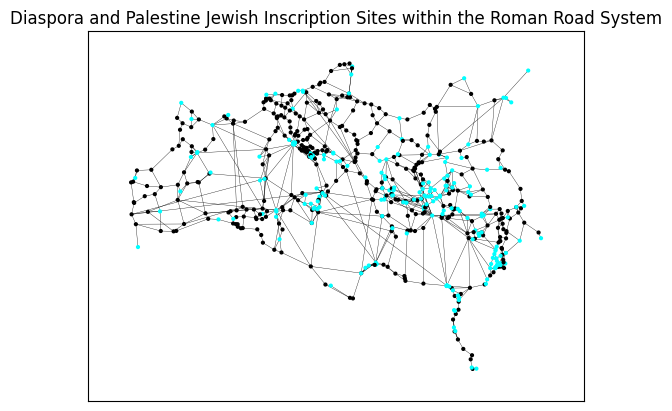

In [ ]:
## New inscription map

# TODO: add borders layer

# colors to use
colors_dict = {0 : "black", 1 : "cyan"}

pos = dict()
color = []
to_drop = []
for n in G_inscr_iip.nodes:
   node_dict = G_inscr_iip.nodes[n]
   if node_dict.get('long') is None: # drop orbis nodes with no long lat
       # print(n, G_inscr_iip.nodes[n])
       to_drop.append(n)
   else:
       pos[n] = (G_inscr_iip.nodes[n]['long'], G_inscr_iip.nodes[n]['lat'])
       if G_inscr_iip.nodes[n]['inscr']==True:
           color.append(1)
       else: color.append(0)

for n in to_drop:
    G_inscr_iip.remove_node(n)

# specify colors:
color = [colors_dict[c] for c in color]

plt.figure()
plt.title('Diaspora and Palestine Jewish Inscription Sites within the Roman Road System')
nx.draw_networkx(G_inscr_iip, pos, node_size=4, width=0.25,
                 node_color=color, with_labels=False)

## Does accessibility to Palestine effect when diaspora sites have inscriptions?

`A` (`A_raw`, `A_uniform`) calculates the "accessibility" of each diaspora site to each of the the Palestinian sites. Unlike our prior calculation we use **inverse** network distance. (That is, we divide by distance. This is analogous to a gravity calculation, but the Physics 101 calculation of gravity uses inverse squared distance.) This means that near sites have high accessibility, and far sites have low accessibility. If a diaspora site is not later than a Palestinian site it is compared to its accessibility is scored as 0.    

From this matrix (diaspora sites x palestine sites), we calculate a single composite number representing the accessibility to Palestine. That number is the sum of accessibility scores, **divided by the number of non-zero scores**. That normalization is important because otherwise a late diaspora site would have a much lower accessibility score than a nearby early diaspora site simply because it is "inaccessible" to earlier sites in Palestine.

In [ ]:
# Accessibility matrix: how reachable is diaspora site p from Palestine site j
# if diaspora site is earier than palestine site accessibility = 0
# inverse distance means near sites have high accessibility,
# far sites have low accessibility

def build_accessibility_matrix(d_bar_diaspora, d_bar_palestine,
                                km_dist, eps=1.0):
    """
    Build the (n_diaspora x n_palestine) matrix of temporally-filtered
    inverse-distance terms, before weighting.

    A_raw[j, p] = 1 / d_km(j, p)   if d_bar_p < d_bar_j
                  0                  otherwise

    For each Palestine, Diaspora site pair: get the accessibility pressure
    Since the Palestine sites are uniformly weighted,
    accessibility_pressure is 1/distance betw sites if they fit
    temporally, 0 if they do not fit temporally

    Parameters
    ----------
    d_bar_diaspora  : pd.Series  index=diaspora idx
    d_bar_palestine : pd.Series  index=palestine idx
    km_dist         : pd.DataFrame  rows=all site idx, cols=all site idx
                      precomputed shortest-path km distances
    eps             : float minimum distance floor (km)
                      avoids dividing by distance = 0

    Returns
    -------
    A_raw : np.ndarray  shape (n_diaspora, n_palestine)
    diaspora_idx_order : list  row order
    palestine_idx_order : list  col order
    """
    diaspora_idx_order = list(d_bar_diaspora.index)
    palestine_idx_order = list(d_bar_palestine.index)

    n_j = len(diaspora_idx_order)
    n_p = len(palestine_idx_order)

    A_raw = np.zeros((n_j, n_p))

    for j_pos, j_idx in enumerate(diaspora_idx_order):
        d_bar_j = d_bar_diaspora[j_idx]

        for p_pos, p_idx in enumerate(palestine_idx_order):
            d_bar_p = d_bar_palestine[p_idx]

            # Temporal filter: Palestinian site must predate diaspora site
            if d_bar_p >= d_bar_j:
                continue

            # Distance lookup
            try:
                d_km = km_dist.loc[j_idx, p_idx]
            except KeyError:
                continue

            if pd.isna(d_km) or d_km <= 0:
                d_km = eps

            A_raw[j_pos, p_pos] = 1.0 / max(d_km, eps)

    return A_raw, diaspora_idx_order, palestine_idx_order

In [ ]:
# can have weighted accessibility values, we are only using default weights

def compute_accessibility(A_raw, weights):
    """
    A_j = sum_p  w_p * A_raw[j, p]

    Parameters
    ----------
    A_raw   : np.ndarray  shape (n_diaspora, n_palestine)
    weights : np.ndarray  shape (n_palestine,)  sums to 1

    Returns
    -------
    A : np.ndarray  shape (n_diaspora,)
    """
    return A_raw @ weights


In [ ]:
# series representing the mean weighted dates of two sets of inscriptions
# note that I am limiting Palestinian sites to those with "Jewish" inscriptions
diasp_weighted_mean = df_jewish.groupby('idx')['weighted_date'].mean()
pal_weighted_mean = df_iip_jewish.groupby('idx')['weighted_date'].mean()

In [ ]:
A_raw, diaspora_idx_order, palestine_idx_order = build_accessibility_matrix(
    diasp_weighted_mean,
    pal_weighted_mean,
    df_dist_km_iip_extended, eps=1.0)

In [ ]:
# Count non-zero entries per diaspora site (row-wise)
n_eligible = (A_raw > 0).sum(axis=1)  # shape (n_diaspora,)

# We are assuming that no "source" or "target" sites have special weight
# An alternative method might give different sites different weights
weights_uniform = np.ones(len(palestine_idx_order)) / len(palestine_idx_order)

# Normalize row sums by eligible count
A_normalized = (A_raw @ weights_uniform) / n_eligible

A_series_normalized = pd.Series(A_normalized,
                                  index=diaspora_idx_order,
                                  name='accessibility_normalized')
rho_accessibility, spearman_p = spearmanr(A_series_normalized, diasp_weighted_mean.values)

print('Correlation (Spearman rho) with weighted mean date:')
print(f"Accessibility pressure rho: {rho_accessibility:.4f}, pval = {spearman_p:.4f}")

Correlation (Spearman rho) with weighted mean date:
Accessibility pressure rho: -0.2680, pval = 0.0002


The correlation is negative as expected: sites with greater access to Palestine (higher scores) tend to have earlier (smaller) dates. It is statistically significant, but relatively low. However, Palestine sites are also on the eastern end of the extended Orbis dataset. So accessibility to Palestine and East-West dispersion are covariant.     
Partial correlation (where we control for the the correlation East-West distribution on date) shows that the Spearman correlation between accessibility to Palestine and date is small (-0.18), but consistently negative (the 95% confidence interval does not cross zero) and statistically significant:

In [ ]:
# recalculate `r_j` relative network position for diaspora inscr sites on km weighting
# have calculated earlier, and could save and reuse
anchor_data_e, anchor_data_w = east_west_anchors_on_graph(G_orbis_extended,'km',orbis_nodes_extended_iip,'med_axis')
east_anchor = anchor_data_e[0]
west_anchor = anchor_data_w[0]
r_j = df_dist_km[east_anchor]/(df_dist_km[west_anchor] + df_dist_km[east_anchor])

# for one to one comparison with accessibility , filter to use only sites with inscriptions
r_j_aligned = r_j.reindex(diasp_weighted_mean.index)

df_partial = pd.DataFrame({
    'date': diasp_weighted_mean.values,
    'A_j':  A_series_normalized,
    'r_j':  r_j_aligned
}).dropna()

result = pg.partial_corr(data=df_partial,
                          x='A_j',
                          y='date',
                          covar='r_j',
                          method='spearman')
print(result)

            n         r            CI95     p_val
spearman  191 -0.180243  [-0.31, -0.04]  0.012828


## Observations
Collectively, when filtered temporally, there is  a very small negative correlation (the expected sign) between accessibility to sites in Palestine and date of inscriptions, after we control for the East-West distribution. Additional tests (resampling both the diaspora and Palestine sites; stratifying the inscription sites into chronological bands) gave inconsistent results, but there is certainly more work that could be done.   
What we can't show (although it is not implausible) is that Palestine, assuming the premise of that inscriptions serve as a proxy for migration, served as an ongoing reservoir for migration westward.